# **Разведотчный анализ (EDA) и конструирование признаков (Feature engineering)**
#### Для Kaggle соревнования [**Dota 2 - HSE ML-1 Course Competition 2026**](https://www.kaggle.com/competitions/dota-2-hse-ml-1-course-competition-2026/overview) в рамках курса "Машинное обучение-1" на ПМИ, ВШЭ ФКН.

### **Сетап**

<img style="float: right; padding-right:15px; padding-bottom:10px" src="https://i.postimg.cc/26KqqSb2/pomoika2.png" height=300px width=200px alt="Pomoika 2">
    
В этом ноубуке мы будем работать с задачей классификации, но сконцентрируемся на том, что приносит не меньшую пользу, чем сами модели — замешиванию данных.

Оценивать качество модели будем через $\text{ROC-AUC}$, но не простой, а коэффициент Джини:

$$ \text{Gini} = 2 \cdot \text{ROC-AUC} - 1$$

Конечная цель данного мероприятия — собрать пайплайн машинного обучения от и до, начиная с предобработки данных, заканчивая оптимизацией.

In [1]:
from sklearn.metrics import roc_auc_score


def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

#### **Данные**

У нас есть датасет по широко известной в неузких кругах видеоигре Dota 2, скачанный через OpenDota API и заботливо анонимизированный. Сам датасет доступен в рамках [Kaggle соревнования](https://www.kaggle.com/competitions/dota-2-hse-ml-1-course-competition-2026), которое в свою очередь было доступно в рамках курса "Машинное обучение-1".

Нас интересует исход матча — победа или поражение, исходя из совершенно разных факторов. Это информация о сессии, игроках, героях, и т д. **в первые 15 минут** после начала матча.

Краткая сводка об игре:

- Dota 2 — командная игра: 5 игроков за Свет (Radiant) против 5 за Тьму (Dire).
- Каждый игрок управляет уникальным героем со своим набором атрибутов и способностей.
- Цель — снести главную постройку на вражеской базе (в простонародье трон).
- В процессе матча игроки добывают золото и опыт, покупают предметы и убивают противников, чтобы стать сильнее.
- Ничьих не бывает, фиксированного таймера нет — матч длится до падения трона.

**Блок импортов и настроек:**

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import roc_auc_score, make_scorer, r2_score
import category_encoders

import zipfile
import os

In [3]:
%config InlineBackend.figure_format = 'retina'

sns.set(style='darkgrid', palette='deep')

plt.rcParams['figure.figsize'] = 8, 5
plt.rcParams['font.size'] = 12
plt.rcParams['savefig.format'] = 'pdf'

### **Часть 1. Это, так сказать, база.**

В этой части будет произведено ознакомление с данными и минимальный EDA.

Скачаем датасет:

In [4]:
# Для этого надо установить kaggle токен. Как это сделать, вот: https://github.com/Kaggle/kaggle-cli
# Ну или самому закинуть zip-ник и забить на этот блок

%pip install kaggle -q
!kaggle competitions download -c dota-2-hse-ml-1-course-competition-2026

Note: you may need to restart the kernel to use updated packages.
dota-2-hse-ml-1-course-competition-2026.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
data_folder_name = 'data_folder'

with zipfile.ZipFile('dota-2-hse-ml-1-course-competition-2026.zip', 'r') as zip_ref:
    zip_ref.extractall(data_folder_name)

Создадим df под нужные csv-шки и выведем инфу про файлы:

In [6]:
match_df_train = pd.read_csv(f'{data_folder_name}/matches_df_train.csv')
match_df_test = pd.read_csv(f'{data_folder_name}/matches_df_test.csv')

train_size = os.path.getsize(f'{data_folder_name}/matches_df_train.csv')
test_size = os.path.getsize(f'{data_folder_name}/matches_df_test.csv')

print(f"Для matches_df_train.csv: вес файла {train_size / (1024 * 1024):.2f} MB, shape - {match_df_train.shape}")
print(f"Для matches_df_train.csv: вес файла {test_size / (1024 * 1024):.2f} MB, shape - {match_df_test.shape}")

Для matches_df_train.csv: вес файла 28.96 MB, shape - (641090, 7)
Для matches_df_train.csv: вес файла 2.08 MB, shape - (59748, 5)


In [7]:
print("Для matches_df_train.csv:")
match_df_train.info(memory_usage='deep')
print("="*48)
print("Для matches_df_train.csv:")
match_df_test.info(memory_usage='deep')


Для matches_df_train.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641090 entries, 0 to 641089
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   match_id     641090 non-null  int64  
 1   date         641090 non-null  object 
 2   region       641090 non-null  object 
 3   game_mode    641090 non-null  int64  
 4   duration     641090 non-null  int64  
 5   radiant_win  641090 non-null  bool   
 6   avg_mmr      472334 non-null  float64
dtypes: bool(1), float64(1), int64(3), object(2)
memory usage: 92.5 MB
Для matches_df_train.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59748 entries, 0 to 59747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   match_id   59748 non-null  int64  
 1   date       59748 non-null  object 
 2   region     59748 non-null  object 
 3   game_mode  59748 non-null  int64  
 4   avg_mmr    44504 non-null  

Отдельно посмотрим на распределение целевой переменной

radiant_win
True     0.510772
False    0.489228
Name: proportion, dtype: float64


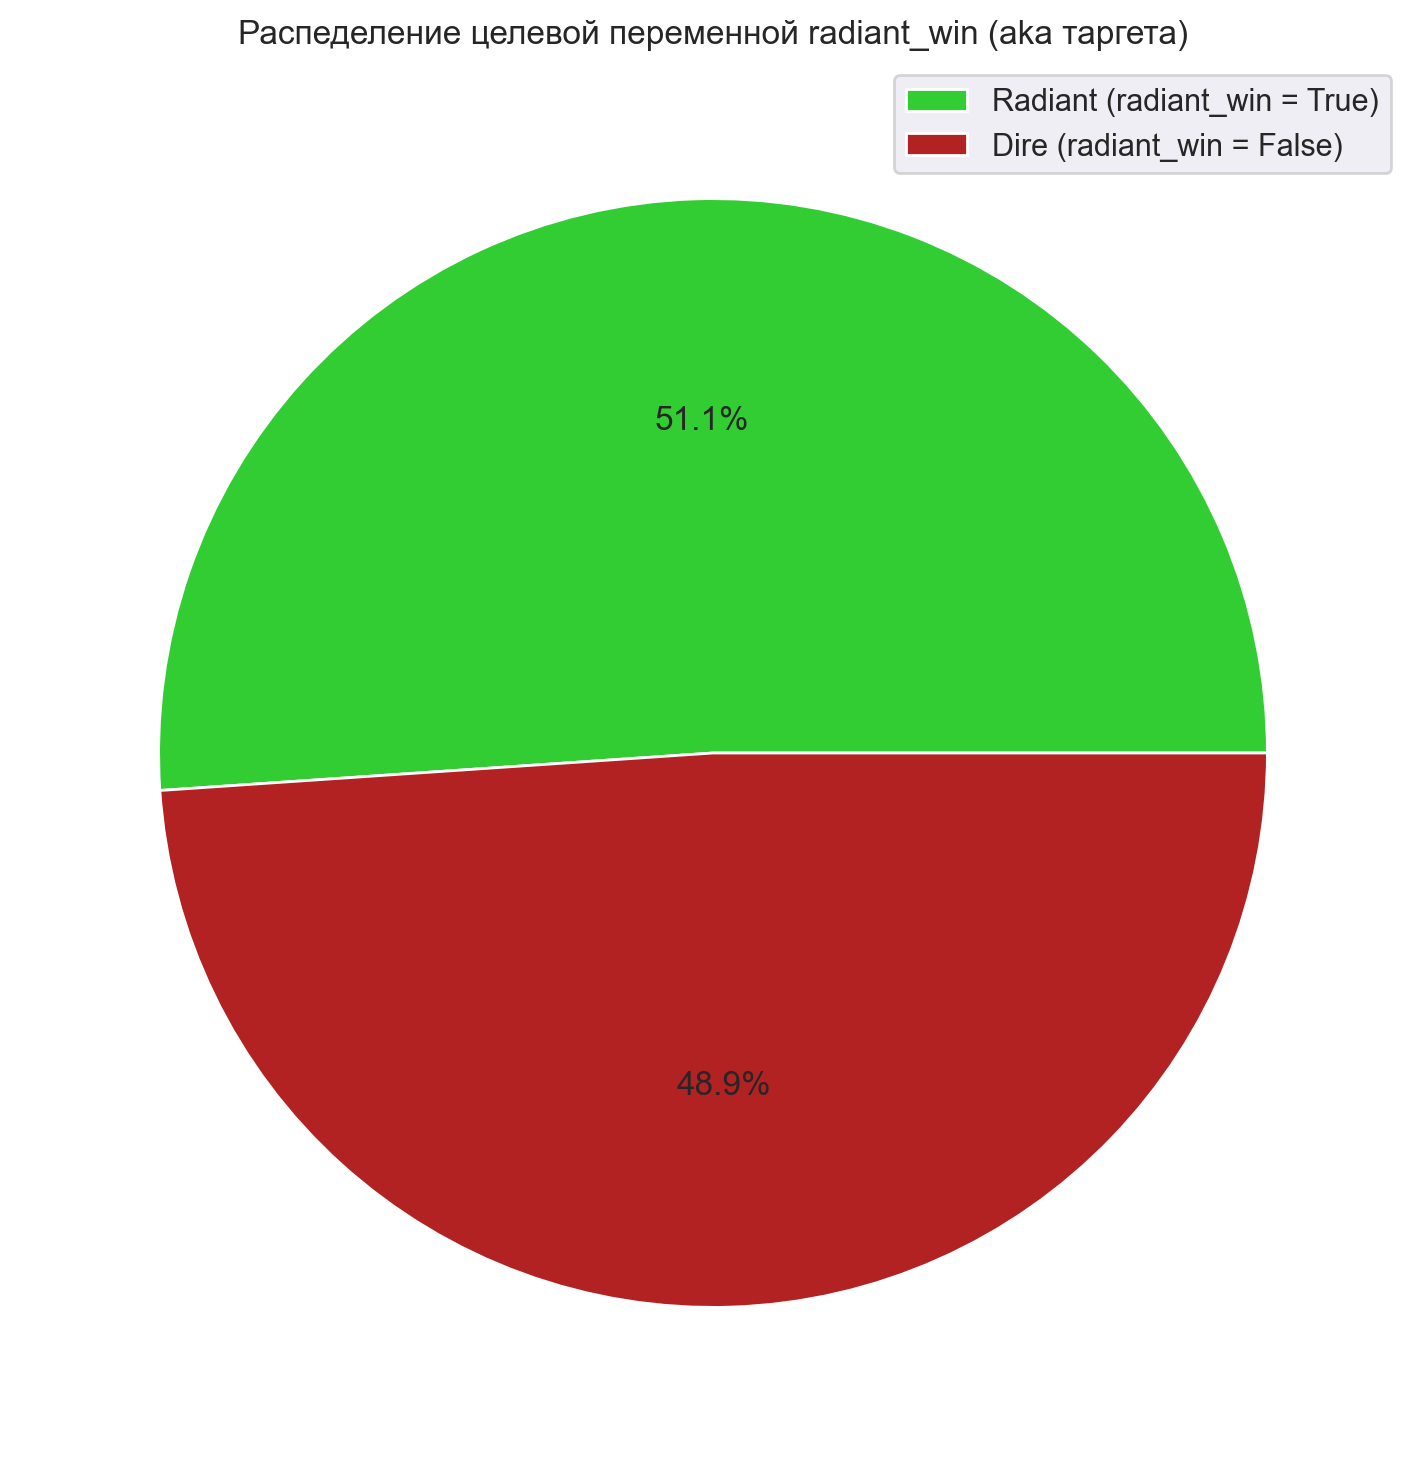

In [8]:
target = "radiant_win"

print(match_df_train[target].value_counts(normalize=True))
target_distribution = match_df_train[target].value_counts()

plt.figure(figsize=(9, 9))
plt.pie(
    target_distribution,
    autopct='%1.1f%%',
    colors = ['#32CD32', "#B22222"]
)
plt.title("Распеделение целевой переменной radiant_win (aka таргета)")
plt.legend(["Radiant (radiant_win = True)", "Dire (radiant_win = False)"])
plt.show()

У нас балланс классов: оба класса близки к 50%. Для таких задач $\text{Gini}$ подходит лучше всех. $\text{AUC-PR}$ лучше себя показывает при дизбалансе классов.

##### **Начнем изучать признаки**

##### **Регион**

У Radiant, по сравнению с Dire, исторически есть небольшое преимущество — чуть удобнее карта, порядок выбора героев и всё такое. В разных регионах бывают разные предпочтения по стилям игры и тактикам, и где-то это преимущество реализуют лучше.

Посмотрим, где у нас содержится информация о регионе, на серверах которого был проведён матч, и построим 2 графика:
1) Распределение регионов (процентное и абсолютное) на тренировочных и тестовых данных
2) Среднее значение таргета на трейне, в зависимости от региона

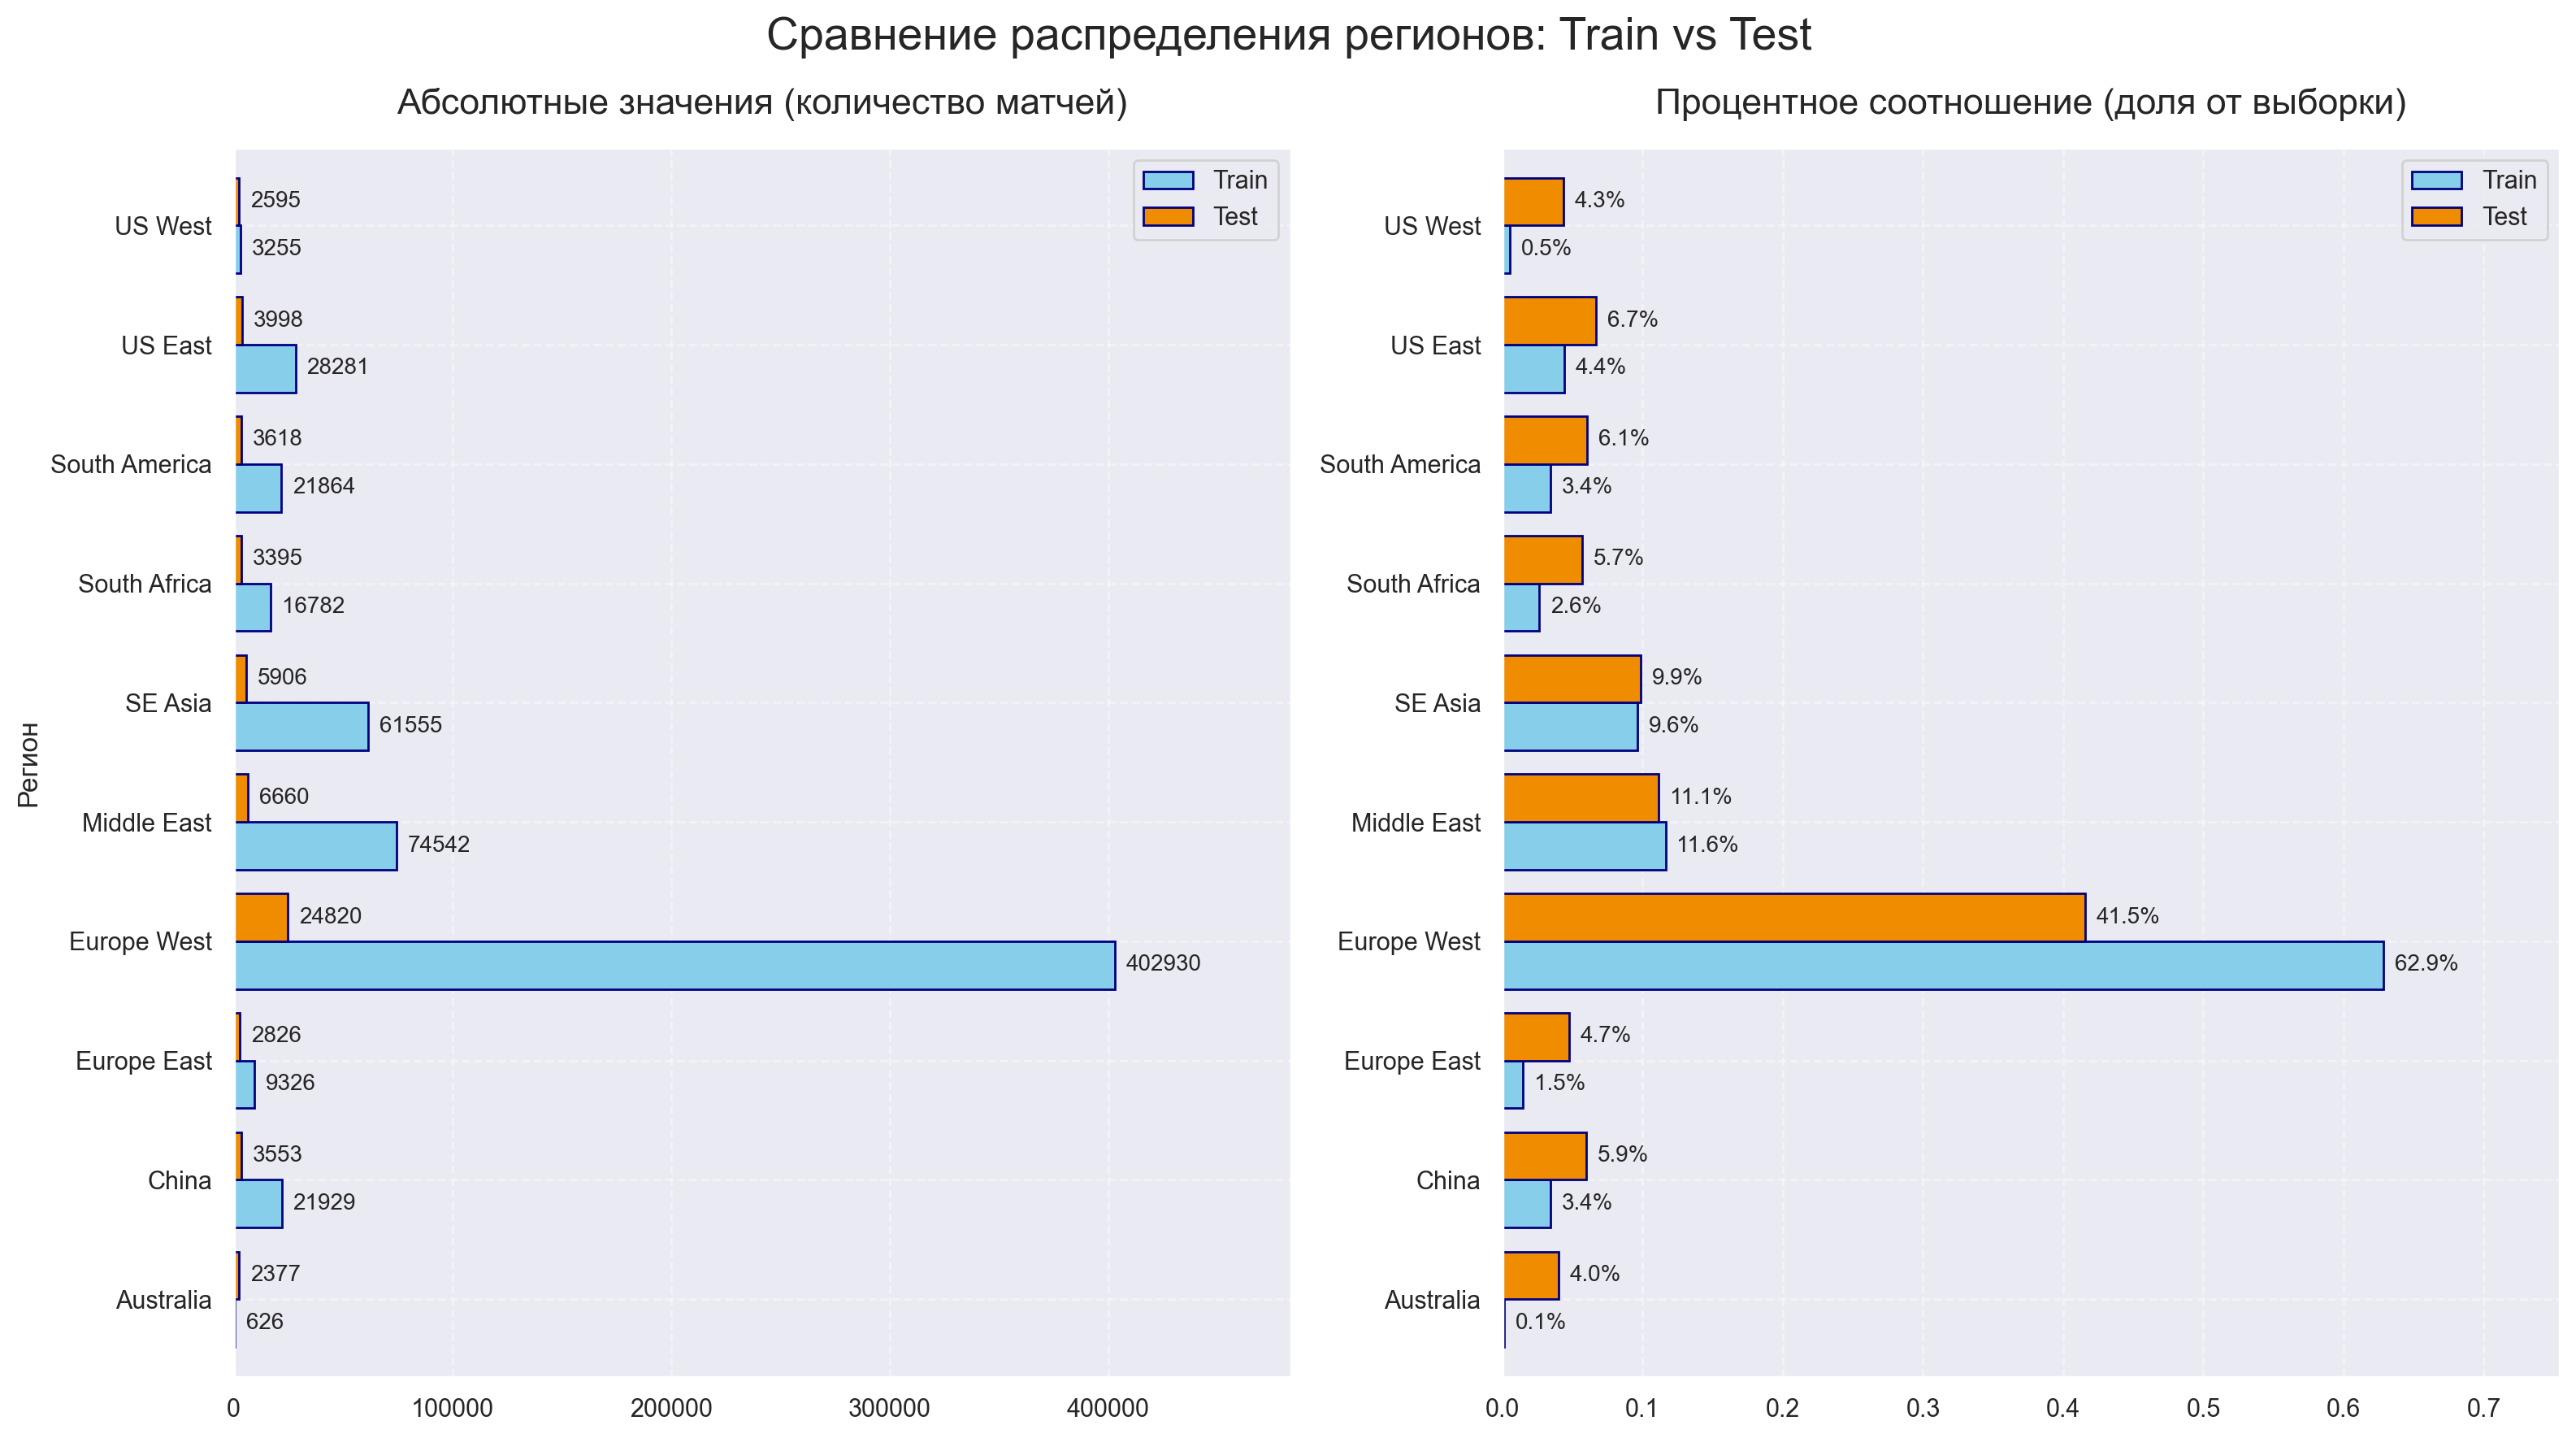

In [9]:
train_counts = match_df_train["region"].value_counts()
test_counts = match_df_test["region"].value_counts()

train_percents = match_df_train["region"].value_counts(normalize=True)
test_percents = match_df_test["region"].value_counts(normalize=True)

df_abs = pd.DataFrame({'Train': train_counts, 'Test': test_counts}).fillna(0).sort_index()
df_pct = pd.DataFrame({'Train': train_percents, 'Test': test_percents}).fillna(0).sort_index()

plt.figure(figsize=(16, 9))
plt.suptitle("Сравнение распределения регионов: Train vs Test", fontsize=20)

plot_configs = [
    (df_abs, "Абсолютные значения (количество матчей)", lambda val: f"{int(val)}"),
    (df_pct, "Процентное соотношение (доля от выборки)", lambda val: f"{val:.1%}")
]

colors = ['skyblue', '#EF8C00']

for idx, (df_to_plot, title, fmt_func) in enumerate(plot_configs, 1):
    ax = plt.subplot(1, 2, idx)

    df_to_plot.plot(kind='barh', ax=ax, color=colors, edgecolor='navy', width=0.8)

    for container in ax.containers:
        labels = [fmt_func(v) if v > 0 else "" for v in container.datavalues]
        ax.bar_label(container, labels=labels, padding=5, fontsize=10)

    ax.set_title(title, fontsize=16, pad=15)
    ax.set_ylabel("Регион" if idx == 1 else "")
    ax.grid(linestyle='--', alpha=0.4)

    ax.set_xlim(0, df_to_plot.max().max() * 1.2)

plt.tight_layout()
plt.show()

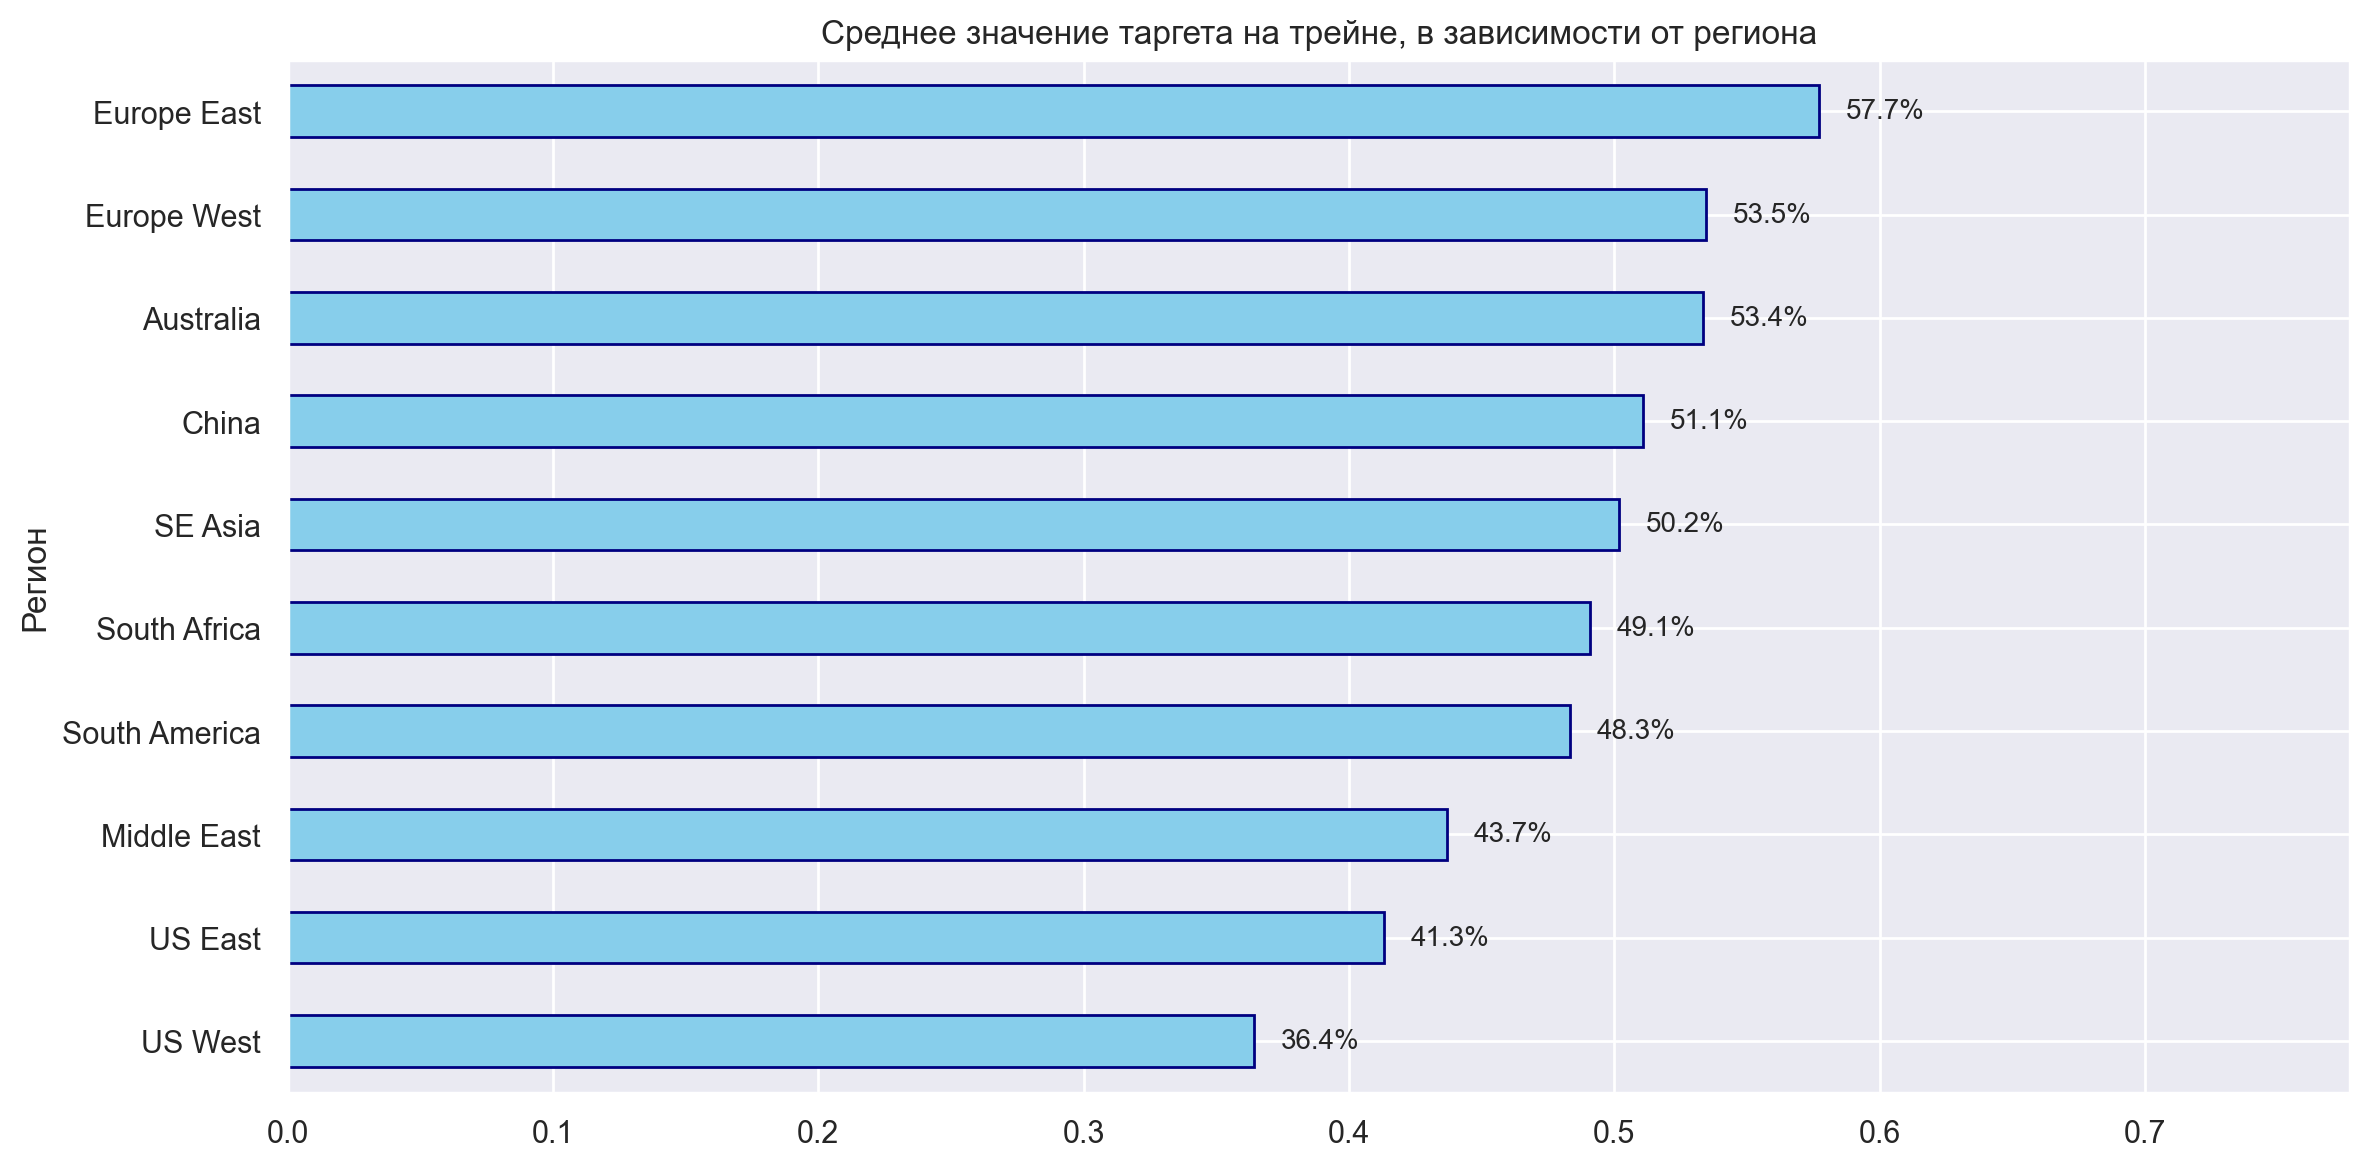

In [10]:
target_distribution = match_df_train.groupby("region")[target].mean().sort_values()

plt.figure(figsize=(12, 6))

ax = target_distribution.plot(kind='barh', color='skyblue', edgecolor='navy')

for index, p in enumerate(target_distribution):
    ax.text(p + 0.01, index, f'{p:.1%}', va='center', fontsize=10)

plt.title("Среднее значение таргета на трейне, в зависимости от региона")
plt.ylabel("Регион")
plt.xlim(0, max(target_distribution) + 0.2)

plt.tight_layout()
plt.show()

Есть значимые различия между распределением регионов на тесте и трейне: ощутимо изменяется значение *Europe West* (62.9% $\rightarrow$ 41.5%), а также другие классы на трейне получают прирост. Это называется Data Drift и это не есть хорошо: модель может переобучиться под доминирующий регион, которого в реальных данных может оказаться не так много. 

А вот распределение среднего значения таргета (вирейта) по регионам показало отчетливую зависимость от региона: от 36% до 58%. В таком скупом датасете это отличный признак для обучения.

Из графиков и результатов выше было принято решение закодировать `region` с помощью **TargetEncoder**'а. В будущем учтем это в пайплайне. А пока для экпериментов будем использовать промежуточный вариант через библиотеку `category_encoders`.

In [11]:
smoothing = 10

target_encoder = category_encoders.TargetEncoder(cols=["region"], smoothing=smoothing)
match_df_train["target_rate_by_region"]  = target_encoder.fit_transform(match_df_train["region"], match_df_train[target])
match_df_test["target_rate_by_region"] = target_encoder.transform(match_df_test["region"])

##### **Время**
Если нам хочется видеть будущее, именно время диктует, что брать можно, а что никак нельзя. Начнем изучать временные ряды:

1. Построим график доли побед Radiant в зависимости от даты матча
2. Сравним временные диапазоны на трейне и тесте

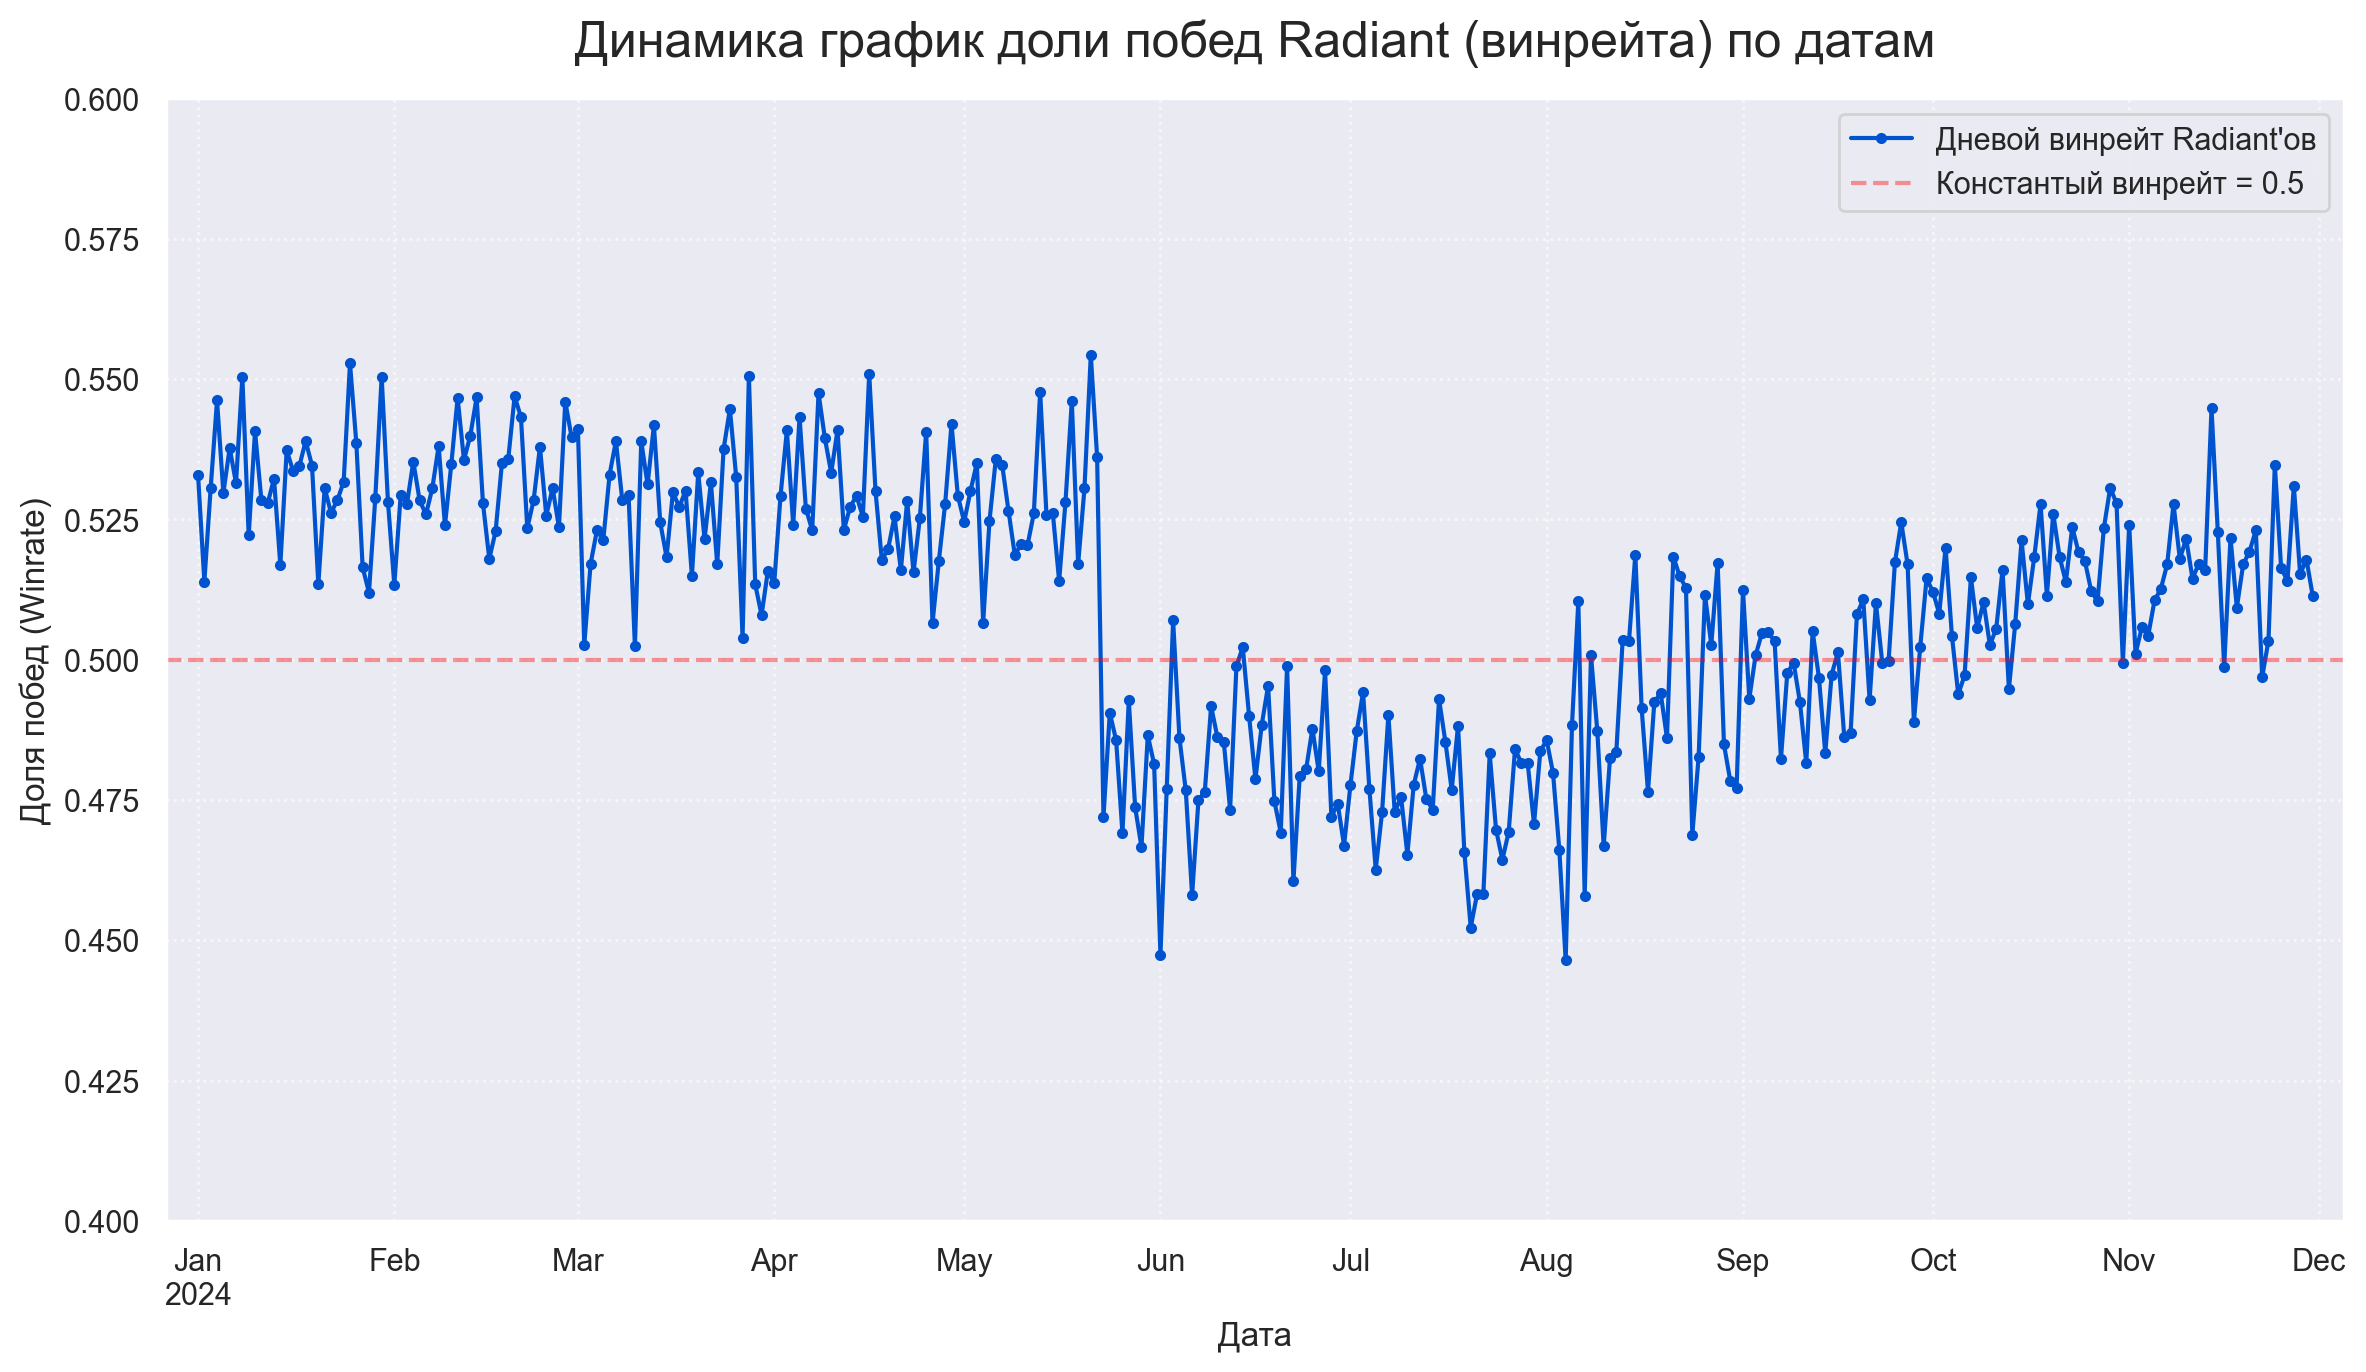

In [12]:
match_df_train["date"] = pd.to_datetime(match_df_train["date"])
match_df_test["date"]= pd.to_datetime(match_df_test["date"])

train_winrate_by_data = match_df_train.groupby("date")[target].mean()

plt.figure(figsize=(12, 7))

train_winrate_by_data.plot(kind='line', color="#0053CF", marker='o', markersize=3, label="Дневой винрейт Radiant'ов")

plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='Константый винрейт = 0.5')

plt.title("Динамика график доли побед Radiant (винрейта) по датам", fontsize=18, pad=15)

plt.xlabel("Дата", fontsize=12)
plt.ylabel("Доля побед (Winrate)", fontsize=12)
plt.ylim(0.4, 0.6)

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
start_date = train_winrate_by_data.index.min()
end_date = train_winrate_by_data.index.max()
plt.xlim(start_date - pd.Timedelta(days=5), end_date + pd.Timedelta(days=5))

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [13]:
print(f"Выборка train содержит данные из диапазона: {match_df_train["date"].min()} -- {match_df_train["date"].max()}")
print(f"Выборка test  содержит данные из диапазона: {match_df_test["date"].min()} -- {match_df_test["date"].max()}")

Выборка train содержит данные из диапазона: 2024-01-01 00:00:00 -- 2024-11-30 00:00:00
Выборка test  содержит данные из диапазона: 2024-12-01 00:00:00 -- 2024-12-31 00:00:00


Что-то странное происходит временным рядом вирейта: сначала Radiant'ы побеждали чаше до середины мая, а после стали чаще проигрывать до середины августа. До декабря винрейт опять начал расти. 

Я в доту играл 30 минут и предпочту больше не играть, поэтому я знать не знаю, что там было. Но благодаря ресурсу Интернет я нашел следующую причину: в Dota 2 действовал патч 7.35 (вышедший в декабре 2023). Он принес серьезные изменения предметов, которые косвенно помогали стратегиям Radiant. А вот следующий патч крупный патч 7.36 сильно поменял правила игры. Норм инфы я не нашел, но ресурс Gemini сказал, что на старте традиционные герои тьмы стали переапанными + патч изменил механику взаимодействия с картой, и старые привычки игроков за Свет перестали работать.

Насколько инфа выше правда не знаю. Я не ~~любитель чужих мам~~ дотер (они же вроде мам любят трогать). 

Также я спросил у знакомого дотера (о чем сожалею), и получил ответ:
"ну у меня такая идея типо для скиловых игроков игра за редиант проще, но когда наступает лето приток лоускильных школьников, для которых наоборот редиант сложен, да, можем заметить после лета постепенный отток школоты".

Ничего умного, связанного с логикой доты я не придумать не могу. Но я понял, что после патча 7.36 в игре что-то сильно поменялось, это видно и винрейту, поэтому это полезная фича (я так считаю). Также можно взять флаг выходного дня: на выходных как правило добавляется более казуальная (или пивная) аудитория. Но возьмем все такие номер дня недели, вдруг у дотеров среда какой-то особенный день. Тем более это не так сильно раздует пространство фич. Объязательно будем использовать **OneHotEncoder**.

In [14]:
patch_date = pd.to_datetime("2024-05-23")

match_df_train["is_match_before_patch_7_36"] = (match_df_train["date"] < patch_date).astype(int)
match_df_test["is_match_before_patch_7_36"] = (match_df_test["date"] < patch_date).astype(int)

match_df_train["day_of_week"] = match_df_train["date"].dt.dayofweek
match_df_test["day_of_week"] = match_df_test["date"].dt.dayofweek

ohe_encoder = category_encoders.OneHotEncoder(cols=["day_of_week"])
ohe_train = ohe_encoder.fit_transform(match_df_train["day_of_week"], match_df_train[target])
match_df_train = pd.concat([match_df_train, ohe_train], axis=1)
ohe_test = ohe_encoder.transform(match_df_test["day_of_week"])
match_df_test = pd.concat([match_df_test, ohe_test], axis=1)

In [15]:
# Удаляем одну колонку для ЛНЗ
match_df_train = match_df_train.drop(columns=['day_of_week_1'])
match_df_test = match_df_test.drop(columns=['day_of_week_1'])

Опять же, это промежуточная предобработка для экспериментов. В итоговом пайплайне организуем более аккуратно.

#### Начнем первые экперименты

Надо бы и модель обучить, вот только без валидации это будет как-то не православно, надо озаботиться этим вопросом.

Наши данные чувствительны ко времени. Например, та же ситуация с патчем. До него винрейт был значительно выше, чем после. Поэтому нам важно учитывать течение времени. Будем использовать CV OOT (Cross-Validation Out-of-Time). Хоть это и будет работать дольше, но точно покажет настоящее качество модели (а точнее ее признаков, это для нас важнее).

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import make_scorer

match_df_train = match_df_train.sort_values("date")

n_folds = 20
tscv = TimeSeriesSplit(n_splits=n_folds)

def evaluate_model(features, name):
    model = LogisticRegression(max_iter=2000, random_state=67)

    cv_results = cross_validate(
        model,
        match_df_train[features],
        match_df_train[target],
        cv=tscv,
        scoring=make_scorer(gini, response_method='predict_proba'),
        return_train_score=True
    )

    print(f"{name}:")
    print(f"Средний Gini на Train: {cv_results['train_score'].mean():.4f}")
    print(f"Средний Gini на Val:   {cv_results['test_score'].mean():.4f}")

Обучим первые модели на разных подмножествах фичей.

In [17]:
region_features = ["target_rate_by_region"]
date_features = [col for col in match_df_train.columns if "day_of_week_" in col] + ["is_match_before_patch_7_36"]

evaluate_model(date_features, "Только даты")
print("=" * 29)
evaluate_model(region_features, "Только регионы")
print("=" * 29)
evaluate_model(date_features + region_features, "Даты + Регионы")

Только даты:
Средний Gini на Train: 0.0271
Средний Gini на Val:   0.0093
Только регионы:
Средний Gini на Train: 0.0760
Средний Gini на Val:   0.0754
Даты + Регионы:
Средний Gini на Train: 0.0888
Средний Gini на Val:   0.0742


In [18]:
# уберем фичу патча:
evaluate_model(date_features[:-1], "Только дни недели")
print("=" * 29)
evaluate_model(date_features[:-1] + region_features, "Дни недели + Регионы")

Только дни недели:
Средний Gini на Train: 0.0094
Средний Gini на Val:   0.0068
Дни недели + Регионы:
Средний Gini на Train: 0.0796
Средний Gini на Val:   0.0782


In [19]:
# уберем фичу патча:
evaluate_model(date_features[:-1], "Только дни недели")
print("=" * 29)
evaluate_model(date_features[:-1] + region_features, "Дни недели + Регионы")

Только дни недели:
Средний Gini на Train: 0.0094
Средний Gini на Val:   0.0068
Дни недели + Регионы:
Средний Gini на Train: 0.0796
Средний Gini на Val:   0.0782


Я считал, что флаг патча может помочь. Но из-за того, что до какого-то момента он 1, а после 0: модель переобучается по нему во время валидации по ранним блокам, а после, когда флаг переходит в 0, начинает ошибаться. В общем его точно надо убрать. А вот OHE для дней недели на удивление хорошо себя показал (дал буст к Gini на Val и не привел к переобучению) -- его бы я оставил.

##### **Числовые признаки**

Остался неотвеченным лишь один вопрос — а что числовые признаки?

Одним из числовых признаков является ММР. От ммра напрямую зависит то, как игроки пользуются естественным преимуществом Radiant. Чем игроки сильнее, тем чаще это должно происходить, в теории.

Построим график распределения ммров и сравним, насколько распределения похожи между собой визуально.

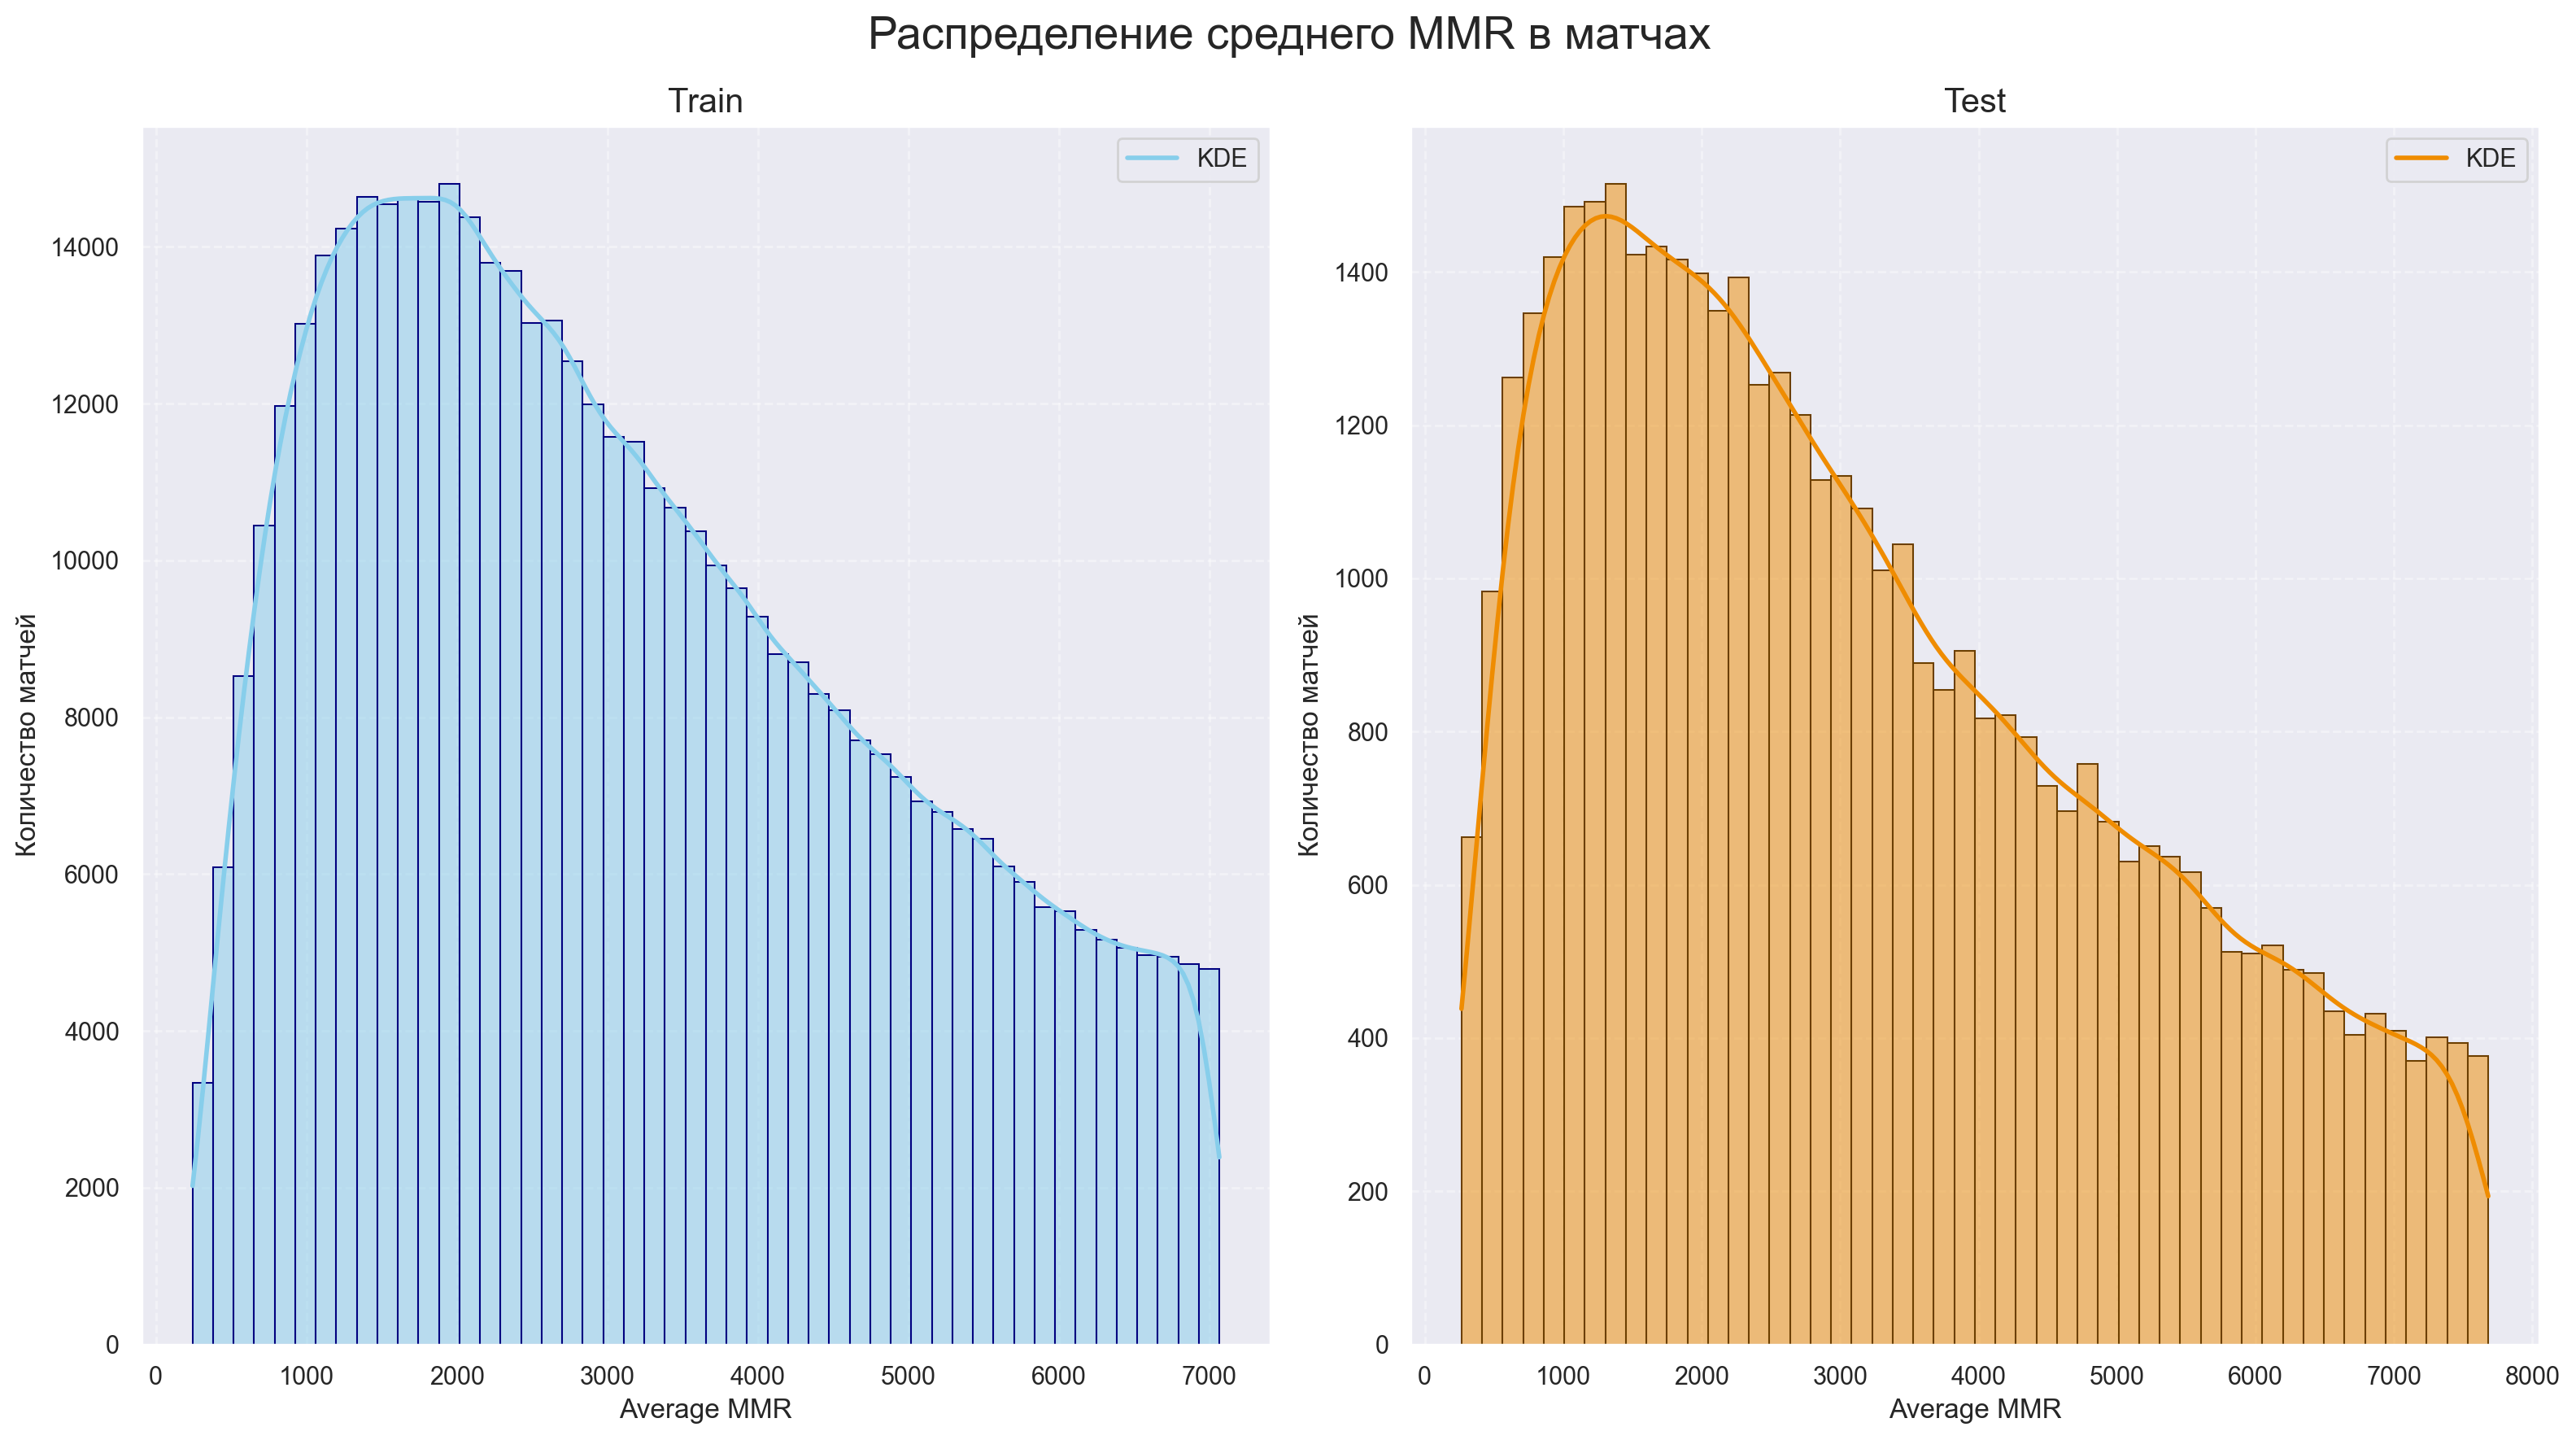

In [20]:
plt.figure(figsize=(16, 9))
plt.suptitle('Распределение среднего MMR в матчах', fontsize=20)


plot_configs = [
    (match_df_train["avg_mmr"], "Train", 'skyblue', 'navy'),
    (match_df_test["avg_mmr"], "Test", '#EF8C00', '#6C3F00')
]

for idx, (df_to_plot, title, color, edge_color) in enumerate(plot_configs, 1):
    plt.subplot(1, 2, idx)
    sns.histplot(df_to_plot, kde=True, color=color, edgecolor=edge_color, bins=50,
        line_kws={
            'linewidth': 2,
            'label': 'KDE'
        }
    )

    plt.title(title, fontsize=15)

    plt.xlabel('Average MMR', fontsize=12)
    plt.ylabel('Количество матчей', fontsize=12)

    plt.legend()
    plt.grid('y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Распределения теста и трейна визуально очень похожи. Это лог-нормальное распределение.

Кто-то где-то говорил, что числовые признаки надо бы стандартизировать, чтобы вышло что-то годное. Этот кто-то прав, но как известно, практика — критерий истины.

Так или иначе, у нас и распределение то не нормальное, но, к счастью, это решаемо. Сделаем такие преобразования признака ммров $f_{\text{mmr}}$ и нарисуем их график:

$$f_{\text{mmr}} \mapsto \log( 1+f_{\text{mmr}} ); \qquad f_{\text{mmr}} \mapsto \sqrt{f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \frac{1}{1+f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \exp{\log f_{\text{mmr}}};$$

Затем выберем какое-то одно и в дальнейшем будем использовать его.

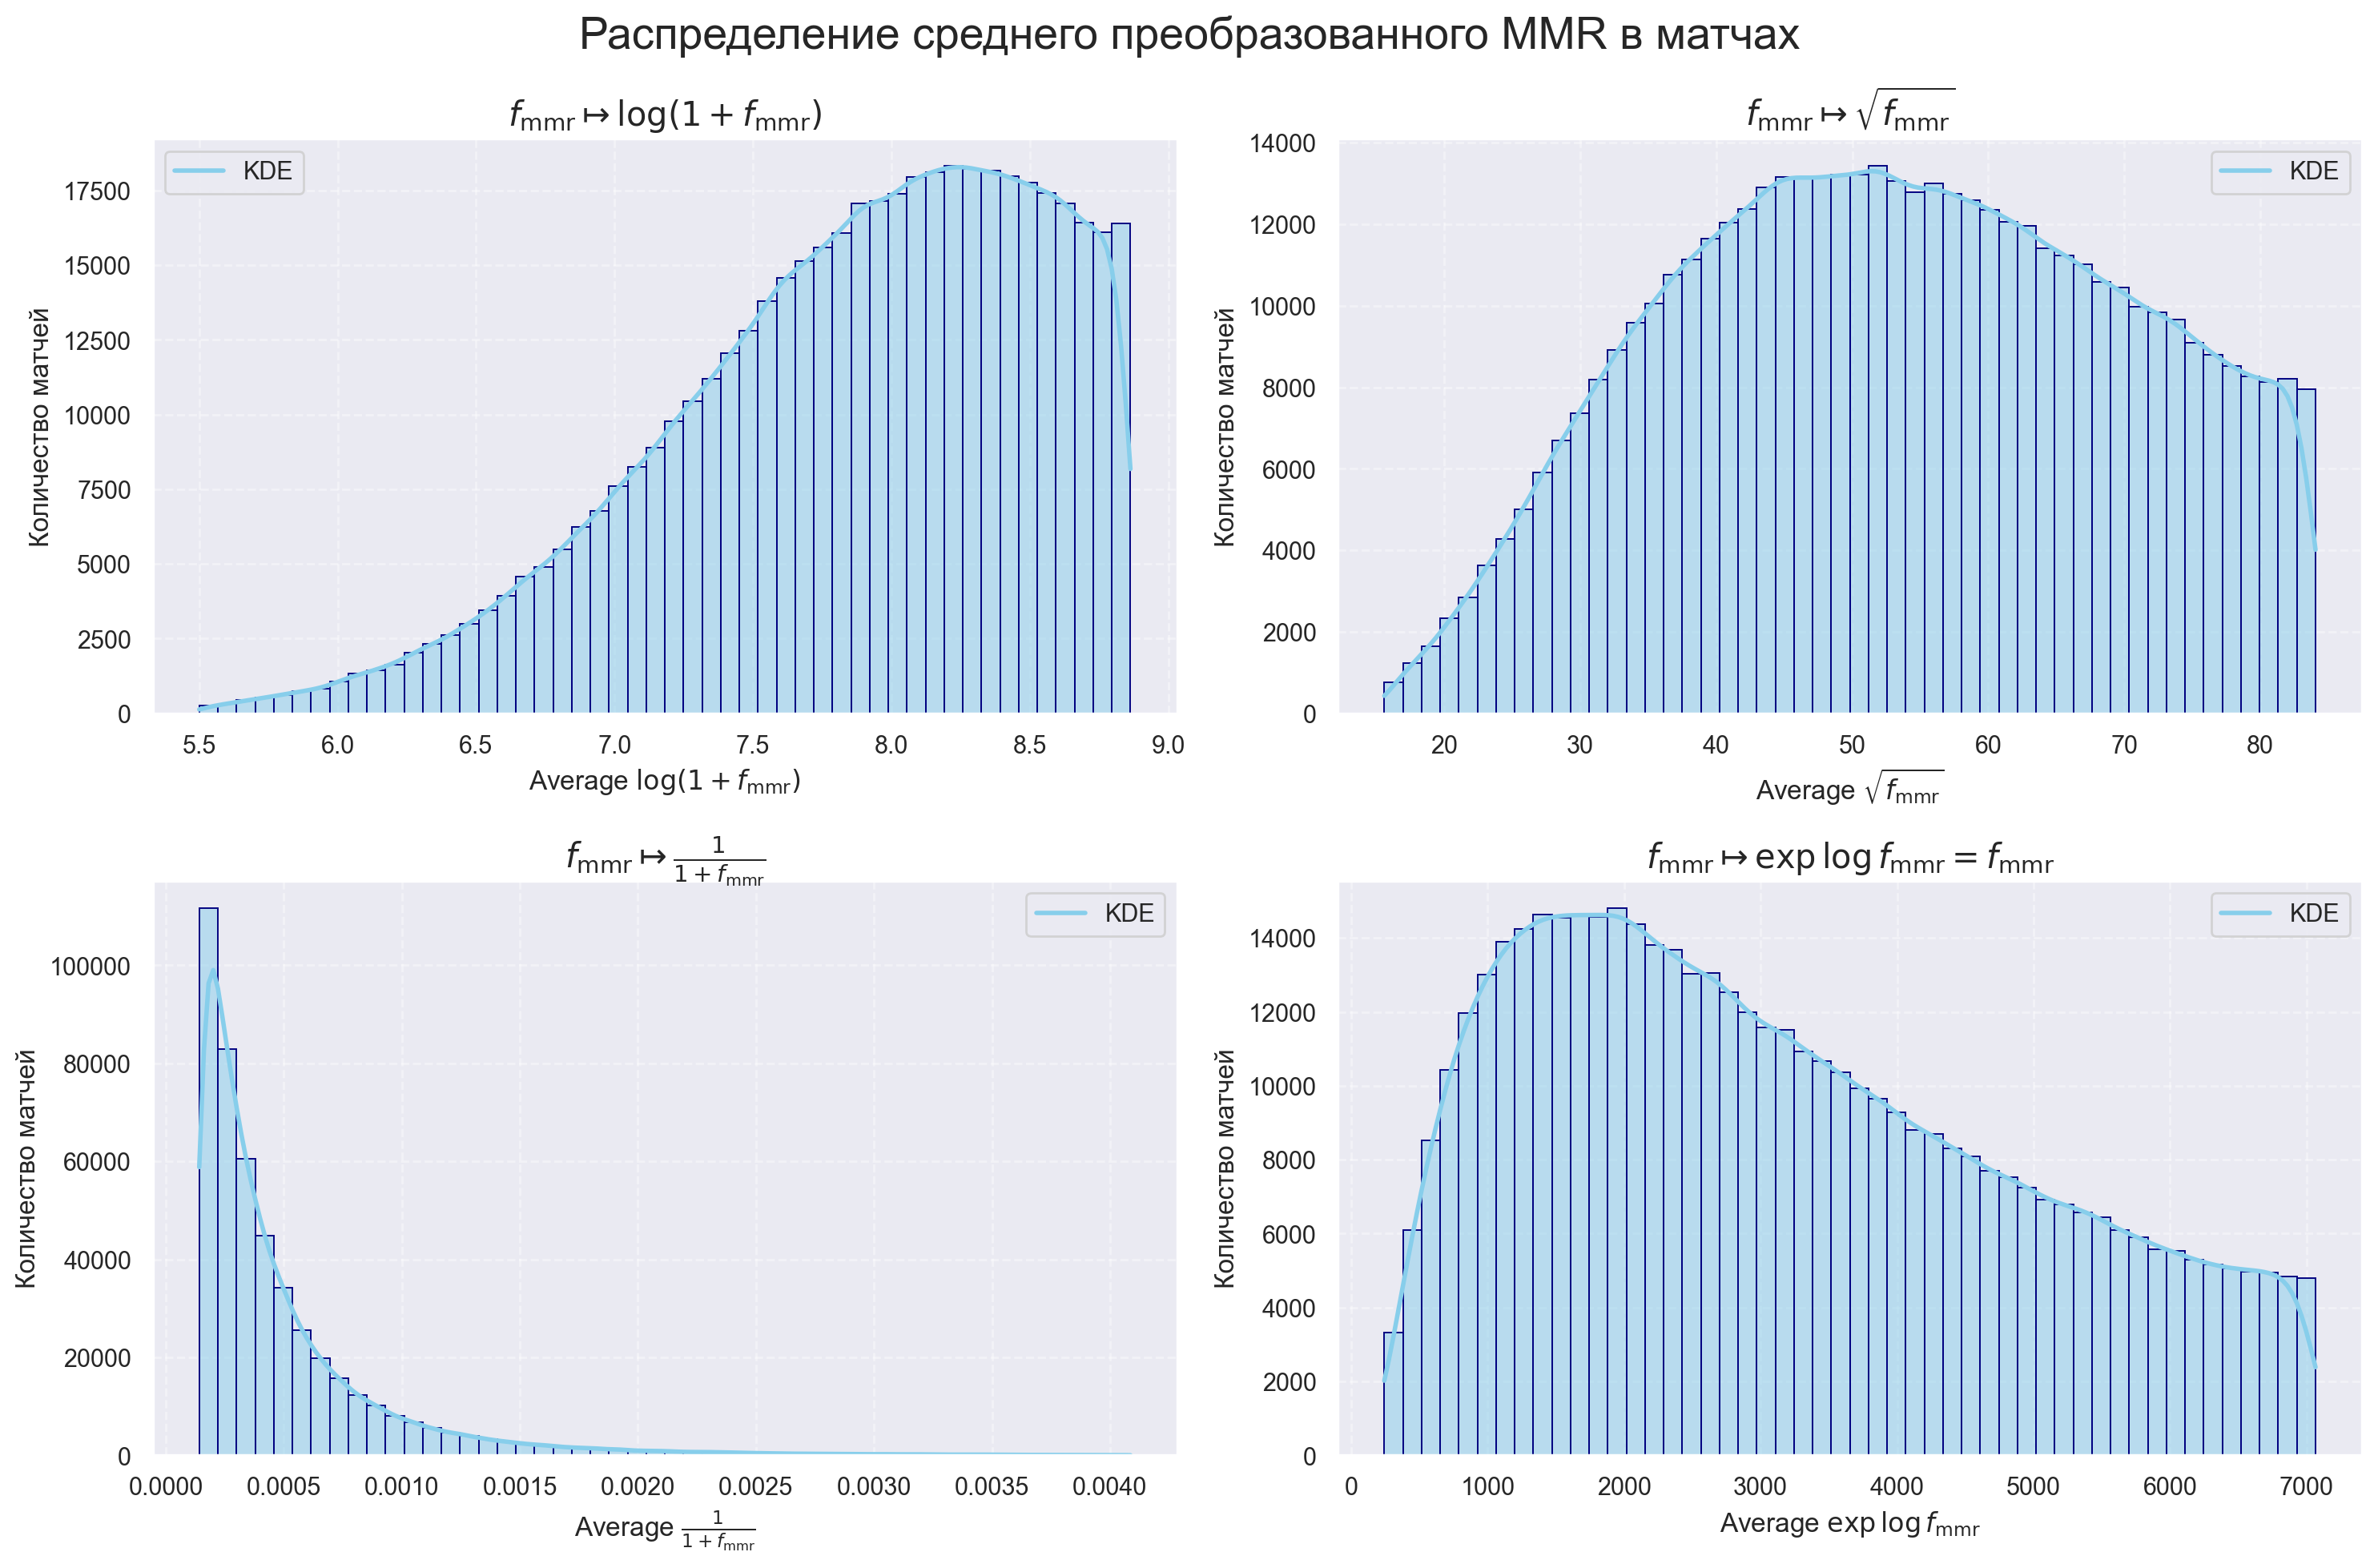

In [21]:
plt.figure(figsize=(15, 10))
plt.suptitle('Распределение среднего преобразованного MMR в матчах', fontsize=20)

# строить будем для train потому что результаты с train'м будут похожие
plot_configs = [
    # (match_df_train["avg_mmr"], r"$f_{\text{mmr}} \mapsto f_{\text{mmr}}$", r"$f_{\text{mmr}}$", 'skyblue', 'navy'),
    (np.log1p(match_df_train["avg_mmr"]), r"$f_{\text{mmr}} \mapsto \log( 1+f_{\text{mmr}})$", r"$\log( 1+f_{\text{mmr}})$", 'skyblue', 'navy'),
    (np.sqrt(match_df_train["avg_mmr"]), r"$f_{\text{mmr}} \mapsto \sqrt{f_{\text{mmr}}}$", r"$\sqrt{f_{\text{mmr}}}$", 'skyblue', 'navy'),
    (1/(1 + match_df_train["avg_mmr"]), r"$f_{\text{mmr}} \mapsto \frac{1}{1+f_{\text{mmr}}}$", r"$\frac{1}{1+f_{\text{mmr}}}$", 'skyblue', 'navy'),
    (np.exp(np.log(match_df_train["avg_mmr"])), r"$f_{\text{mmr}} \mapsto \exp{\log f_{\text{mmr}}}=f_{\text{mmr}}$", r"$\exp{\log f_{\text{mmr}}}$", 'skyblue',  'navy'),
]

for idx, (df_to_plot, title, mmr_func, color, edge_color) in enumerate(plot_configs, 1):
    plt.subplot(2, 2, idx)
    sns.histplot(df_to_plot, kde=True, color=color, edgecolor=edge_color, bins=50,
        line_kws={
            'linewidth': 2,
            'label': 'KDE'
        }
    )

    plt.title(title, fontsize=15)

    plt.xlabel(f'Average {mmr_func}', fontsize=12)
    plt.ylabel('Количество матчей', fontsize=12)

    plt.legend()
    plt.grid('y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Мне больше всего нравится преобразование $f_{\text{mmr}} \mapsto \log( 1+f_{\text{mmr}})$, потому что оно ближе всех к нормальному.

Но надо решить чем заполнять пропуски. Вбычно проставить нули -- плохая идея, в это раз не исключение. Наверное стандартным решением будет заполнить его средним по всей выборке. Или средним значением по значению внутри класса/категориального признака. Но с последней идеей надо быть осторожнее, при маленьком размере множества, по которому мы считаем среднее значение может оказаться нерепрезентативым. Как я понял сейчас этого делать не надо, но я был заполним его средним (мб по региону если будет корреляция, пока просто средним) + добавим бы флаг `mmr_missing`.

Момент истины. Обучим две новые модели: к оптимальному набору фичей, который мы нашли раньше + добавим в одном случае фичу без преобразования, а в другом — после преобразования. Оценим влияние признаков.

In [22]:
optimal_features = date_features[:-1] + region_features

match_df_train = match_df_train.sort_values("date")

match_df_train["mmr_missing"] = match_df_train["avg_mmr"].isna().astype(int)
match_df_test["mmr_missing"] = match_df_test["avg_mmr"].isna().astype(int)

mean_mmr = match_df_train["avg_mmr"].mean()

match_df_train["avg_mmr"] = match_df_train["avg_mmr"].fillna(mean_mmr)
match_df_test["avg_mmr"] = match_df_test["avg_mmr"].fillna(mean_mmr)

match_df_train["tranform_avg_mmr"] = np.log1p(match_df_train["avg_mmr"])
match_df_test["tranform_avg_mmr"] = np.log1p(match_df_test["avg_mmr"])

evaluate_model(optimal_features, "Старый набор фичей")
print("=" * 29)
evaluate_model(optimal_features + ["avg_mmr", "mmr_missing"], "Старый набор фичей + mmr_missing + mmr")
print("=" * 29)
evaluate_model(optimal_features + ["tranform_avg_mmr", "mmr_missing"], "Старый набор фичей + mmr_missing + log(1 + mmr)")

Старый набор фичей:
Средний Gini на Train: 0.0796
Средний Gini на Val:   0.0783
Старый набор фичей + mmr_missing + mmr:
Средний Gini на Train: 0.1467
Средний Gini на Val:   0.1470
Старый набор фичей + mmr_missing + log(1 + mmr):
Средний Gini на Train: 0.1482
Средний Gini на Val:   0.1482


In [23]:
optimal_features = optimal_features + ["tranform_avg_mmr", "mmr_missing"]

### **Часть 2. Векторы** <img align="center" height=28 width=28 src="https://static.wikia.nocookie.net/dota2_gamepedia/images/1/17/Emoticon_sick.gif/revision/latest?cb=20180504011850">

#### **Задание 2.1. Большая чистка** (0.75 балла)

Пока что мы никак не использовали информацию про героев, а ведь от них напрямую зависит исход матча, их больше 100 штук и все они разные: кто-то сильнее, кто-то слабее. Только в данные кто-то нагадил, придётся убирать(

Датасеты, которые нас интересуют теперь — `player_df.csv` и `Constants.Heroes.csv`. Там есть и данные на трейне, и на тесте, мы их обязательно приджойним, но потом.

Вытащим данные с csv'ешк:

In [24]:
players_df = pd.read_csv(f'{data_folder_name}/player_df.csv') # а в условии df_player.csv. Обманывать плохо
heroes_df = pd.read_csv(f'{data_folder_name}/Constants.Heroes.csv')

display(players_df.head())
display(heroes_df.head())

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
0,130,10111871,5,3.0,8.0,15.0,2971.0,55.0,3.0,291.0,390.0,7431.0,146.0,215380
1,130,43341844,3,3.0,9.0,3.0,1245.0,25.0,3.0,238.0,346.0,4187.0,34.0,185234
2,130,72157343,53,9.0,6.0,20.0,4544.0,226.0,1.0,583.0,704.0,9406.0,2375.0,573078
3,1,4294967295,17,21.0,3.0,15.0,2945.0,209.0,12.0,577.0,641.0,30957.0,1801.0,366576
4,2,54350942,19,9.0,8.0,8.0,413.0,227.0,9.0,471.0,584.0,18215.0,627.0,455795


,Unnamed: 0,id,name,primary_attr,attack_type,roles,img,icon,base_health,base_health_regen,...,attack_rate,base_attack_time,attack_point,move_speed,turn_rate,cm_enabled,legs,day_vision,night_vision,localized_name
0,0,1,npc_dota_hero_antimage,agi,Melee,"['Carry', 'Escape', 'Nuker']",/apps/dota2/images/dota_react/heroes/antimage....,/apps/dota2/images/dota_react/heroes/icons/ant...,120,1.00,...,1.4,100,0.30,310,NaN,True,2,1800,800,Anti-Mage
1,1,2,npc_dota_hero_axe,str,Melee,"['Initiator', 'Durable', 'Disabler', 'Carry']",/apps/dota2/images/dota_react/heroes/axe.png?,/apps/dota2/images/dota_react/heroes/icons/axe...,120,2.50,...,1.7,100,0.40,315,NaN,True,2,1800,800,Axe
2,2,3,npc_dota_hero_bane,all,Ranged,"['Support', 'Disabler', 'Nuker', 'Durable']",/apps/dota2/images/dota_react/heroes/bane.png?,/apps/dota2/images/dota_react/heroes/icons/ban...,120,0.25,...,1.7,100,0.30,305,NaN,True,4,1800,1200,Bane
3,3,4,npc_dota_hero_bloodseeker,agi,Melee,"['Carry', 'Disabler', 'Nuker', 'Initiator']",/apps/dota2/images/dota_react/heroes/bloodseek...,/apps/dota2/images/dota_react/heroes/icons/blo...,120,0.25,...,1.7,100,0.43,285,NaN,True,2,1800,800,Bloodseeker
4,4,5,npc_dota_hero_crystal_maiden,int,Ranged,"['Support', 'Disabler', 'Nuker']",/apps/dota2/images/dota_react/heroes/crystal_m...,/apps/dota2/images/dota_react/heroes/icons/cry...,120,0.25,...,1.7,100,0.45,280,NaN,True,2,1800,800,Crystal Maiden


Первое, что нужно отсмотреть - главные ключи. Начнём с игроков. Поверим `account_id`:

In [25]:
players_df.value_counts("account_id")

account_id
 4294967295    2795673
-1               27267
 37619671          801
 84244723          763
 87266522          761
                ...   
 122269001           1
 33101108            1
 122268567           1
 122268297           1
 114526777           1
Name: count, Length: 974931, dtype: int64

С первыми двумя первыми айдишниками очевидно какая-то проблема. $-1$ обычно заглушка, по всей видимости `account_id` = $4294967295$ -- тоже. Выведем в относительное распределение:

In [26]:
players_df.value_counts("account_id", normalize=True).head(15).to_frame().style.format('{:.4%}')

,proportion
account_id,
4294967295,36.5408%
-1,0.3564%
37619671,0.0105%
84244723,0.0100%
87266522,0.0099%
38584608,0.0098%
85427446,0.0097%
62933415,0.0097%
151993649,0.0097%


Выкинуть все "плохие" мы точно не можем. `account_id` = $4294967295$ составляет почти 37% датасета. Как я понял это как раз игроки с анонимными профилями. А вот данные с `account_id` = $-1$ в целом можно выкинуть -- их доля не такая значительная + это более вероятная ошибка в данных (-1 обычно заглушка при какой-то ошибке). Выкинем их. 

In [27]:
players_df[players_df["account_id"] == -1]

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
153,1,-1,44,15.0,14.0,6.0,1146.0,99.0,23.0,472.0,678.0,20610.0,258.0,519759
208,129,-1,99,2.0,6.0,0.0,441.0,32.0,0.0,230.0,249.0,3236.0,0.0,380288
266,0,-1,26,4.0,6.0,10.0,1668.0,20.0,8.0,251.0,387.0,7626.0,135.0,78412
468,130,-1,35,1.0,11.0,6.0,493.0,37.0,16.0,225.0,226.0,3405.0,0.0,139264
710,0,-1,32,19.0,1.0,9.0,1422.0,73.0,0.0,397.0,455.0,20446.0,240.0,483564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7649692,131,-1,37,1.0,5.0,4.0,515.0,44.0,21.0,243.0,306.0,3212.0,402.0,411972
7649905,129,-1,32,11.0,4.0,14.0,544.0,105.0,19.0,520.0,667.0,18080.0,650.0,258567
7650128,128,-1,30,9.0,13.0,5.0,271.0,13.0,9.0,258.0,216.0,11769.0,0.0,493065
7650410,129,-1,99,1.0,13.0,7.0,600.0,51.0,0.0,223.0,216.0,6096.0,49.0,484493


In [28]:
players_df = players_df[players_df["account_id"] != -1]

Следующий логический шаг — одинаковых героев быть в одном матче не должно. Изучим и полечим эту проблему.

In [29]:
heors_by_match = players_df.groupby("match_id")["hero_id"].value_counts().to_frame()

dublicated_heroes = heors_by_match[heors_by_match["count"] != 1]

display(dublicated_heroes)
print(f"Доля матчей с дубликатами героев: {(dublicated_heroes.count() / heors_by_match.count()).iloc[0]:.4%}")

,,count
match_id,hero_id,
59,39,2
264,11,2
268,11,2
561,0,4
1646,11,2
...,...,...
765001,0,4
765163,0,10
765182,0,10


Доля матчей с дубликатами героев: 0.0139%


Получили копеешную долю, поэтому такие матчи лучше дропнуть. Сделаем это.

In [30]:
bad_match_ids = dublicated_heroes.reset_index()["match_id"].unique()

players_df = players_df[~players_df["match_id"].isin(bad_match_ids)]

Если вы посмотреть в `Constants.Heroes.csv`, то героя с id 0 в дасете нет, а вот в логах матчей есть. Это ошибка, почистим такие матчи. И в целом провалидируем данные.

Посмотрим, что за игроки играли на герое с `hero_id=0`.

In [31]:
zero_heroes = players_df[players_df["hero_id"] == 0]
display(zero_heroes)
zero_heroes.value_counts("account_id").to_frame()

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
15873,129,98709905,0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,253222
27247,130,4294967295,0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,548366
32401,129,135024675,0,0.0,0.0,0.0,0.0,0.0,0.0,121.0,0.0,0.0,0.0,587247
32541,0,4294967295,0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,299419
33785,129,120989008,0,0.0,0.0,0.0,0.0,0.0,0.0,157.0,0.0,0.0,0.0,97776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7572342,0,4294967295,0,0.0,0.0,0.0,0.0,0.0,0.0,105.0,0.0,0.0,0.0,4767
7585936,3,4294967295,0,0.0,0.0,0.0,0.0,0.0,0.0,120.0,0.0,0.0,0.0,622437
7605989,2,216331489,0,0.0,0.0,0.0,0.0,0.0,0.0,228.0,0.0,0.0,0.0,666154
7635133,128,155042350,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,377081


,count
account_id,
4294967295,387
80971241,8
89311828,4
83699997,2
187026099,2
...,...
101783814,1
101488892,1
101388302,1


Какие-то рандомные игроки с нулевой статистикой, дропнем такие матчи.

In [32]:
bad_match_ids = zero_heroes["match_id"].unique()

players_df = players_df[~players_df["match_id"].isin(bad_match_ids)]

Теперь найдем игроков, которые в одном матче играли одновременно и за команду сил Тьмы (слоты `{128, ..., 132}`), и за команду сил Света (слоты `{0, ..., 4}`), не являясь $4294967295$ и $-1$.

In [33]:
real_account_id_mask = ~players_df["account_id"].isin([4294967295, -1])

players_df["is_radiant_team"] = players_df["player_slot"].isin(range(0, 5)).astype(int)

player_team_by_match = players_df[real_account_id_mask].groupby(["match_id", "account_id"])["is_radiant_team"].nunique()
player_team_by_match[player_team_by_match > 1]

Series([], Name: is_radiant_team, dtype: int64)

Таких игроков нет, нам повезло, спасибо.

Отфильтруем `player_df`: оставим только те матчи, которые есть в наших выборках.

In [34]:
datasets_match_ids = np.unique(np.concatenate([match_df_train["match_id"].unique(), match_df_test["match_id"].unique()]))

players_df = players_df[players_df["match_id"].isin(datasets_match_ids)]

Проверим, что в каждом матче ровно 5 игроков за Свет и ровно 5 за Тьму.

In [35]:
count_players_by_match = players_df.groupby(["match_id", "is_radiant_team"])["account_id"].count()

bad_matches = count_players_by_match[count_players_by_match != 5].reset_index()
display(bad_matches.head())
print(f"Количество матчей с неправильным количеством игроков в одной из команд: {bad_matches.shape[0]}")

,match_id,is_radiant_team,account_id
0,270883,1,1
1,280288,1,1
2,280690,1,1
3,280848,1,1
4,297080,0,2


Количество матчей с неправильным количеством игроков в одной из команд: 42


Такие есть, не дело. Удалим их, чтобы не было проблем.

In [36]:
bad_match_ids = bad_matches["match_id"].unique()

players_df = players_df[~players_df["match_id"].isin(bad_match_ids)]

Далее перейдем уже к самим героям. План был в том, чтобы закодировать комбинации героев, которые участвуют в матче. Это чуть более сложный признак, чем обычный трансформ, тут придется поколдовать.

Идея в том, что какие-то комбинации героев эффективнее других. Если понять, что в матче за персонажи, можно сразу же прикинуть шансы на победу одной из сторон


Закодируем каждый матч вектором вида:

| match_id | hero_1 | hero_2 | hero_3 | ... | hero_n |
| --- | --- | --- | --- | --- | --- |
| 228 | 1 | 0 | -1 | ... | 0 |


Хочется написать класс, который вертит фичами вот так:

Каждый элемент в векторе матча `(hero_1, ..., hero_n)` принимает значение 1, если герой был в команде сил Света (слоты `{0, ..., 4}`), и -1, если в команде сил Тьмы (слоты `{128, ..., 132}`). 

In [37]:
heroes_df["id"]

0        1
1        2
2        3
3        4
4        5
      ... 
121    135
122    136
123    137
124    138
125    145
Name: id, Length: 126, dtype: int64

In [38]:
class HeroesEncoder:
    def __init__(self, heroes_df):
        self.hero_columns = [f'hero_{i}' for i in heroes_df["id"].unique()]

    def fit(self, X, y=None):
        pass

    def transform(self, X, y=None):
        # signs = np.where(X['is_radiant_team'] == 1, 1, -1)
        signs = np.where(X["player_slot"].isin(range(0, 5)), 1, -1)
        small_X = pd.DataFrame({
            'match_id': X['match_id'],
            'hero_id': X['hero_id'],
            'team_sign': signs
        })
        match_vectors = small_X.pivot(index='match_id', columns='hero_id', values='team_sign').fillna(0)
        match_vectors.columns = [f'hero_{col}' for col in match_vectors.columns]

        missing_cols = list(set(self.hero_columns) - set(match_vectors.columns))
        if missing_cols:
            zeros_df = pd.DataFrame(0, index=match_vectors.index, columns=missing_cols)
            match_vectors = pd.concat([match_vectors, zeros_df], axis=1)

        return match_vectors[self.hero_columns].astype('int')

Осталось лишь самое сладкое — проверить фичу в деле. Обучите две модели: одну со всеми фичами, что мы накрутили, и одну только с фичами героев, покажите качество

In [39]:
heroes_encoder = HeroesEncoder(heroes_df)
heroes_vectors = heroes_encoder.transform(players_df)

match_df_train = match_df_train.join(heroes_vectors, on="match_id", how="left")
match_df_train[heroes_encoder.hero_columns] = match_df_train[heroes_encoder.hero_columns].fillna(0).astype(int)
match_df_test = match_df_test.join(heroes_vectors, on="match_id", how="left")
match_df_test[heroes_encoder.hero_columns] = match_df_test[heroes_encoder.hero_columns].fillna(0).astype(int)

In [40]:
evaluate_model(optimal_features, "Старый набор фичей")
print("=" * 29)
evaluate_model(heroes_encoder.hero_columns, "Векторы героев")
print("=" * 29)
evaluate_model(optimal_features + heroes_encoder.hero_columns, "Старый набор фичей + векторы героев")
print("=" * 29)

Старый набор фичей:
Средний Gini на Train: 0.1482
Средний Gini на Val:   0.1482
Векторы героев:
Средний Gini на Train: 0.2890
Средний Gini на Val:   0.2846
Старый набор фичей + векторы героев:
Средний Gini на Train: 0.3225
Средний Gini на Val:   0.3184


In [41]:
optimal_features = optimal_features + heroes_encoder.hero_columns

### **Часть 3. Оптимизация** <img height=28 width=28 align="center" src="https://cdn.7tv.app/emote/01H8RPMSBR000133946WK71YXM/1x.avif">

Здесь мы займемся оптимизацией и подбором гиперпараметров.

#### **Optuna**

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. Одно из наиболее удобных — [optuna](https://optuna.org/), которая делает перебор гиперпараметров супер понятным и легким.

Напишим функцию оптимизации для вашего классификатор и подберем вот такие гиперпараметры:

1) Численный — `alpha` у `SGDClassifier` или параметр регуляризации `C` у всех остальных.
2) Категориальный — `solver` у `LogisticRegression`, `loss` у всех остальных
3) Число итераций — `max_iter`. Это не совсем гиперпараметр, но поверьте, обучать модель 100 лет мы не хотим, к тому же это вид неявной регуляризации.

In [42]:
import optuna
from sklearn.model_selection import cross_val_score


def objective(trial):
    # model parameters
    l1_ratio = trial.suggest_categorical("l1_ratio", [1.0, 0.0])
    solver = trial.suggest_categorical('logistic_regression_solver', ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'])
    C = trial.suggest_float("C", 1e-3, 10, log=True)
    smoothing = trial.suggest_float("target_encoding_smoothing", 1, 500, log=True)

    model = LogisticRegression(max_iter=1000, solver=solver, l1_ratio=l1_ratio, C=C)

    target_encoder = category_encoders.TargetEncoder(cols=["region"], smoothing=smoothing)
    match_df_train["target_rate_by_region"]  = target_encoder.fit_transform(match_df_train["region"], match_df_train[target])

    X_train = match_df_train[optimal_features]
    y_train = match_df_train[target]

    try:
        gini_score = cross_val_score(model, X_train, y_train, cv=tscv, scoring=make_scorer(gini, response_method='predict_proba'), error_score=0.0)
    except ValueError:
        raise optuna.exceptions.TrialPruned()

    return gini_score.mean()


study = optuna.create_study(direction="maximize")
# n_trials можно поставить и побольше, но пространство гиперпараметров здесь простое
study.optimize(objective, show_progress_bar=True, n_trials=5, n_jobs=-1)

[I 2026-06-24 21:40:18,711] A new study created in memory with name: no-name-788cfb6d-a5b3-4d64-b81d-83199830afd1


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-06-24 21:40:25,501] Trial 1 pruned. 
[I 2026-06-24 21:40:25,567] Trial 0 pruned. 
[I 2026-06-24 21:41:31,544] Trial 3 finished with value: 0.31840184065737703 and parameters: {'l1_ratio': 0.0, 'logistic_regression_solver': 'newton-cg', 'C': 0.7227441767699099, 'target_encoding_smoothing': 77.32503651233911}. Best is trial 3 with value: 0.31840184065737703.
[I 2026-06-24 21:43:29,814] Trial 4 finished with value: 0.31841615879332086 and parameters: {'l1_ratio': 1.0, 'logistic_regression_solver': 'saga', 'C': 9.818220927210424, 'target_encoding_smoothing': 189.4180860443224}. Best is trial 4 with value: 0.31841615879332086.
[I 2026-06-24 21:44:48,538] Trial 2 finished with value: 0.3184132505950935 and parameters: {'l1_ratio': 0.0, 'logistic_regression_solver': 'sag', 'C': 1.925175419711535, 'target_encoding_smoothing': 2.814707460752153}. Best is trial 4 with value: 0.31841615879332086.


Посмотрим насколько наши гиперпараметры вообще важны.

In [43]:
optuna.visualization.plot_param_importances(study)

Параметр регуляризации имеет вклад ~90% в улучешния скора модели. На втором месте вид регуляризации. А дальше уже тип солвера для логистической регрессии и smoothing для кодирования регионов.

In [44]:
best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)

Лучшие гиперпараметры: {'l1_ratio': 1.0, 'logistic_regression_solver': 'saga', 'C': 9.818220927210424, 'target_encoding_smoothing': 189.4180860443224}


Ну а теперь submission на Каггл оформим. Для начала обучим финальную модель.

### **Часть 4. Агрегации** <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4a/Techies_emoticon.gif/revision/latest?cb=20180504014918">


Есть у нас в данных большой кусок про advantage — преимущество команды сил Света с точностью до минуты, по золоту и опыту, всё так же **в пределах 15 минут**. Лежат они в `dota_adv.csv`. Чем больше число, тем больше шанс на победу — всё просто. Только график, как правило, не линеен.

С ними в очередной раз есть проблемы — необходимо разобраться, как они там лежат, и всё ли там в порядке со значениями, но это меньшая из проблем. А также нарисовать парочку advantage, чтобы было понимание, как они себя ведут.

In [45]:
dota_adv = pd.read_csv(f'{data_folder_name}/dota_adv.csv')
dota_adv = dota_adv[dota_adv["match_id"].isin(datasets_match_ids)]

In [46]:
dota_adv.info()
dota_adv.head()

<class 'pandas.core.frame.DataFrame'>
Index: 700838 entries, 0 to 767821
Data columns (total 3 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          700838 non-null  int64 
 1   radiant_gold_adv  700838 non-null  object
 2   radiant_exp_adv   700838 non-null  object
dtypes: int64(1), object(2)
memory usage: 21.4+ MB


,match_id,radiant_gold_adv,radiant_exp_adv
0,526846,[ 0 159 452 1904 2100 3290 3290 3290 3290 ...,[ 0 68 658 1397 1435 2118 2118 1923 1923 ...
1,511496,[ 0 -151 -141 12 -165 -151 -151 4 377 ...,[ 0 1 -136 243 -270 -8 -8 -169 -169 ...
2,90272,[],[]
3,153647,[],[]
4,694826,[],[]


In [47]:
display(dota_adv.iloc[0]["radiant_gold_adv"])
display(dota_adv.iloc[0]["radiant_exp_adv"])

'[   0  159  452 1904 2100 3290 3290 3290 3290 3859 3859 3087 3087 3849\n 5342 5342]'

'[   0   68  658 1397 1435 2118 2118 1923 1923 1923 2494 3772 3734 4661\n 4661 3311]'

In [48]:
display(dota_adv.value_counts("radiant_gold_adv", normalize=True))

radiant_gold_adv
[]                                                                                                     0.690054
[   0  208  570 1171 1038 2253 2253 2253 2635 2635 2635 2635 3539 2901\n 2901 2121]                    0.000001
[   0  208  578 1342 1553 2119 2119 2378 2875 2625 2625 2625 4363 6338\n 5684 5126]                    0.000001
[   0  208  591  768 1022 1362 1362 1576 1466 1466 2137 2137 1583 3064\n 4793 4793]                    0.000001
[   0  208  613  436 1015 1585 1585 1724 1724 2152 1884 1281 1602 1964\n 1296 1296]                    0.000001
                                                                                                         ...   
[    0  -279   -14  -466  -500  -488  -488  -212  -212  -212  -913  -227\n -1395  -636  -636  -636]    0.000001
[    0  -279   -35    19   -90   159   159   159   159   566   138   633\n   633  -288 -1327 -1012]    0.000001
[    0  -279   -47   234  -213  -375  -375  -375  -375  -375  -375   430\n  -437 -2441 

Результаты удручающие: ~69% матчей не имеют статистики. Но у нас все равно есть с чем работать. Для начала преобразуме это все в нормальные числовые списки.

In [49]:
display(dota_adv[dota_adv["radiant_gold_adv"].str[0] != '['])
display(dota_adv[dota_adv["radiant_exp_adv"].str[0] != '['])

,match_id,radiant_gold_adv,radiant_exp_adv


,match_id,radiant_gold_adv,radiant_exp_adv


In [50]:
def parse_str_to_list(s):
    s = s.strip("[]")
    return np.array([int(x) for x in s.split()])

dota_adv["radiant_gold_adv"] = dota_adv["radiant_gold_adv"].apply(parse_str_to_list)
dota_adv["radiant_exp_adv"] = dota_adv["radiant_exp_adv"].apply(parse_str_to_list)

In [51]:
dota_adv.head()

,match_id,radiant_gold_adv,radiant_exp_adv
0,526846,"[0, 159, 452, 1904, 2100, 3290, 3290, 3290, 32...","[0, 68, 658, 1397, 1435, 2118, 2118, 1923, 192..."
1,511496,"[0, -151, -141, 12, -165, -151, -151, 4, 377, ...","[0, 1, -136, 243, -270, -8, -8, -169, -169, 18..."
2,90272,[],[]
3,153647,[],[]
4,694826,[],[]


In [52]:
dota_adv["lens"] = dota_adv["radiant_gold_adv"].apply(len)
display(dota_adv["lens"].value_counts())

dota_adv["lens"] = dota_adv["radiant_exp_adv"].apply(len)
display(dota_adv["lens"].value_counts())

dota_adv.drop(columns=["lens"], inplace=True)

lens
0     483616
16    217222
Name: count, dtype: int64

lens
0     483616
16    217222
Name: count, dtype: int64

Вот теперь с данными можно работать. Построим график для 2х первых в выборке матчей по каждой колонке.

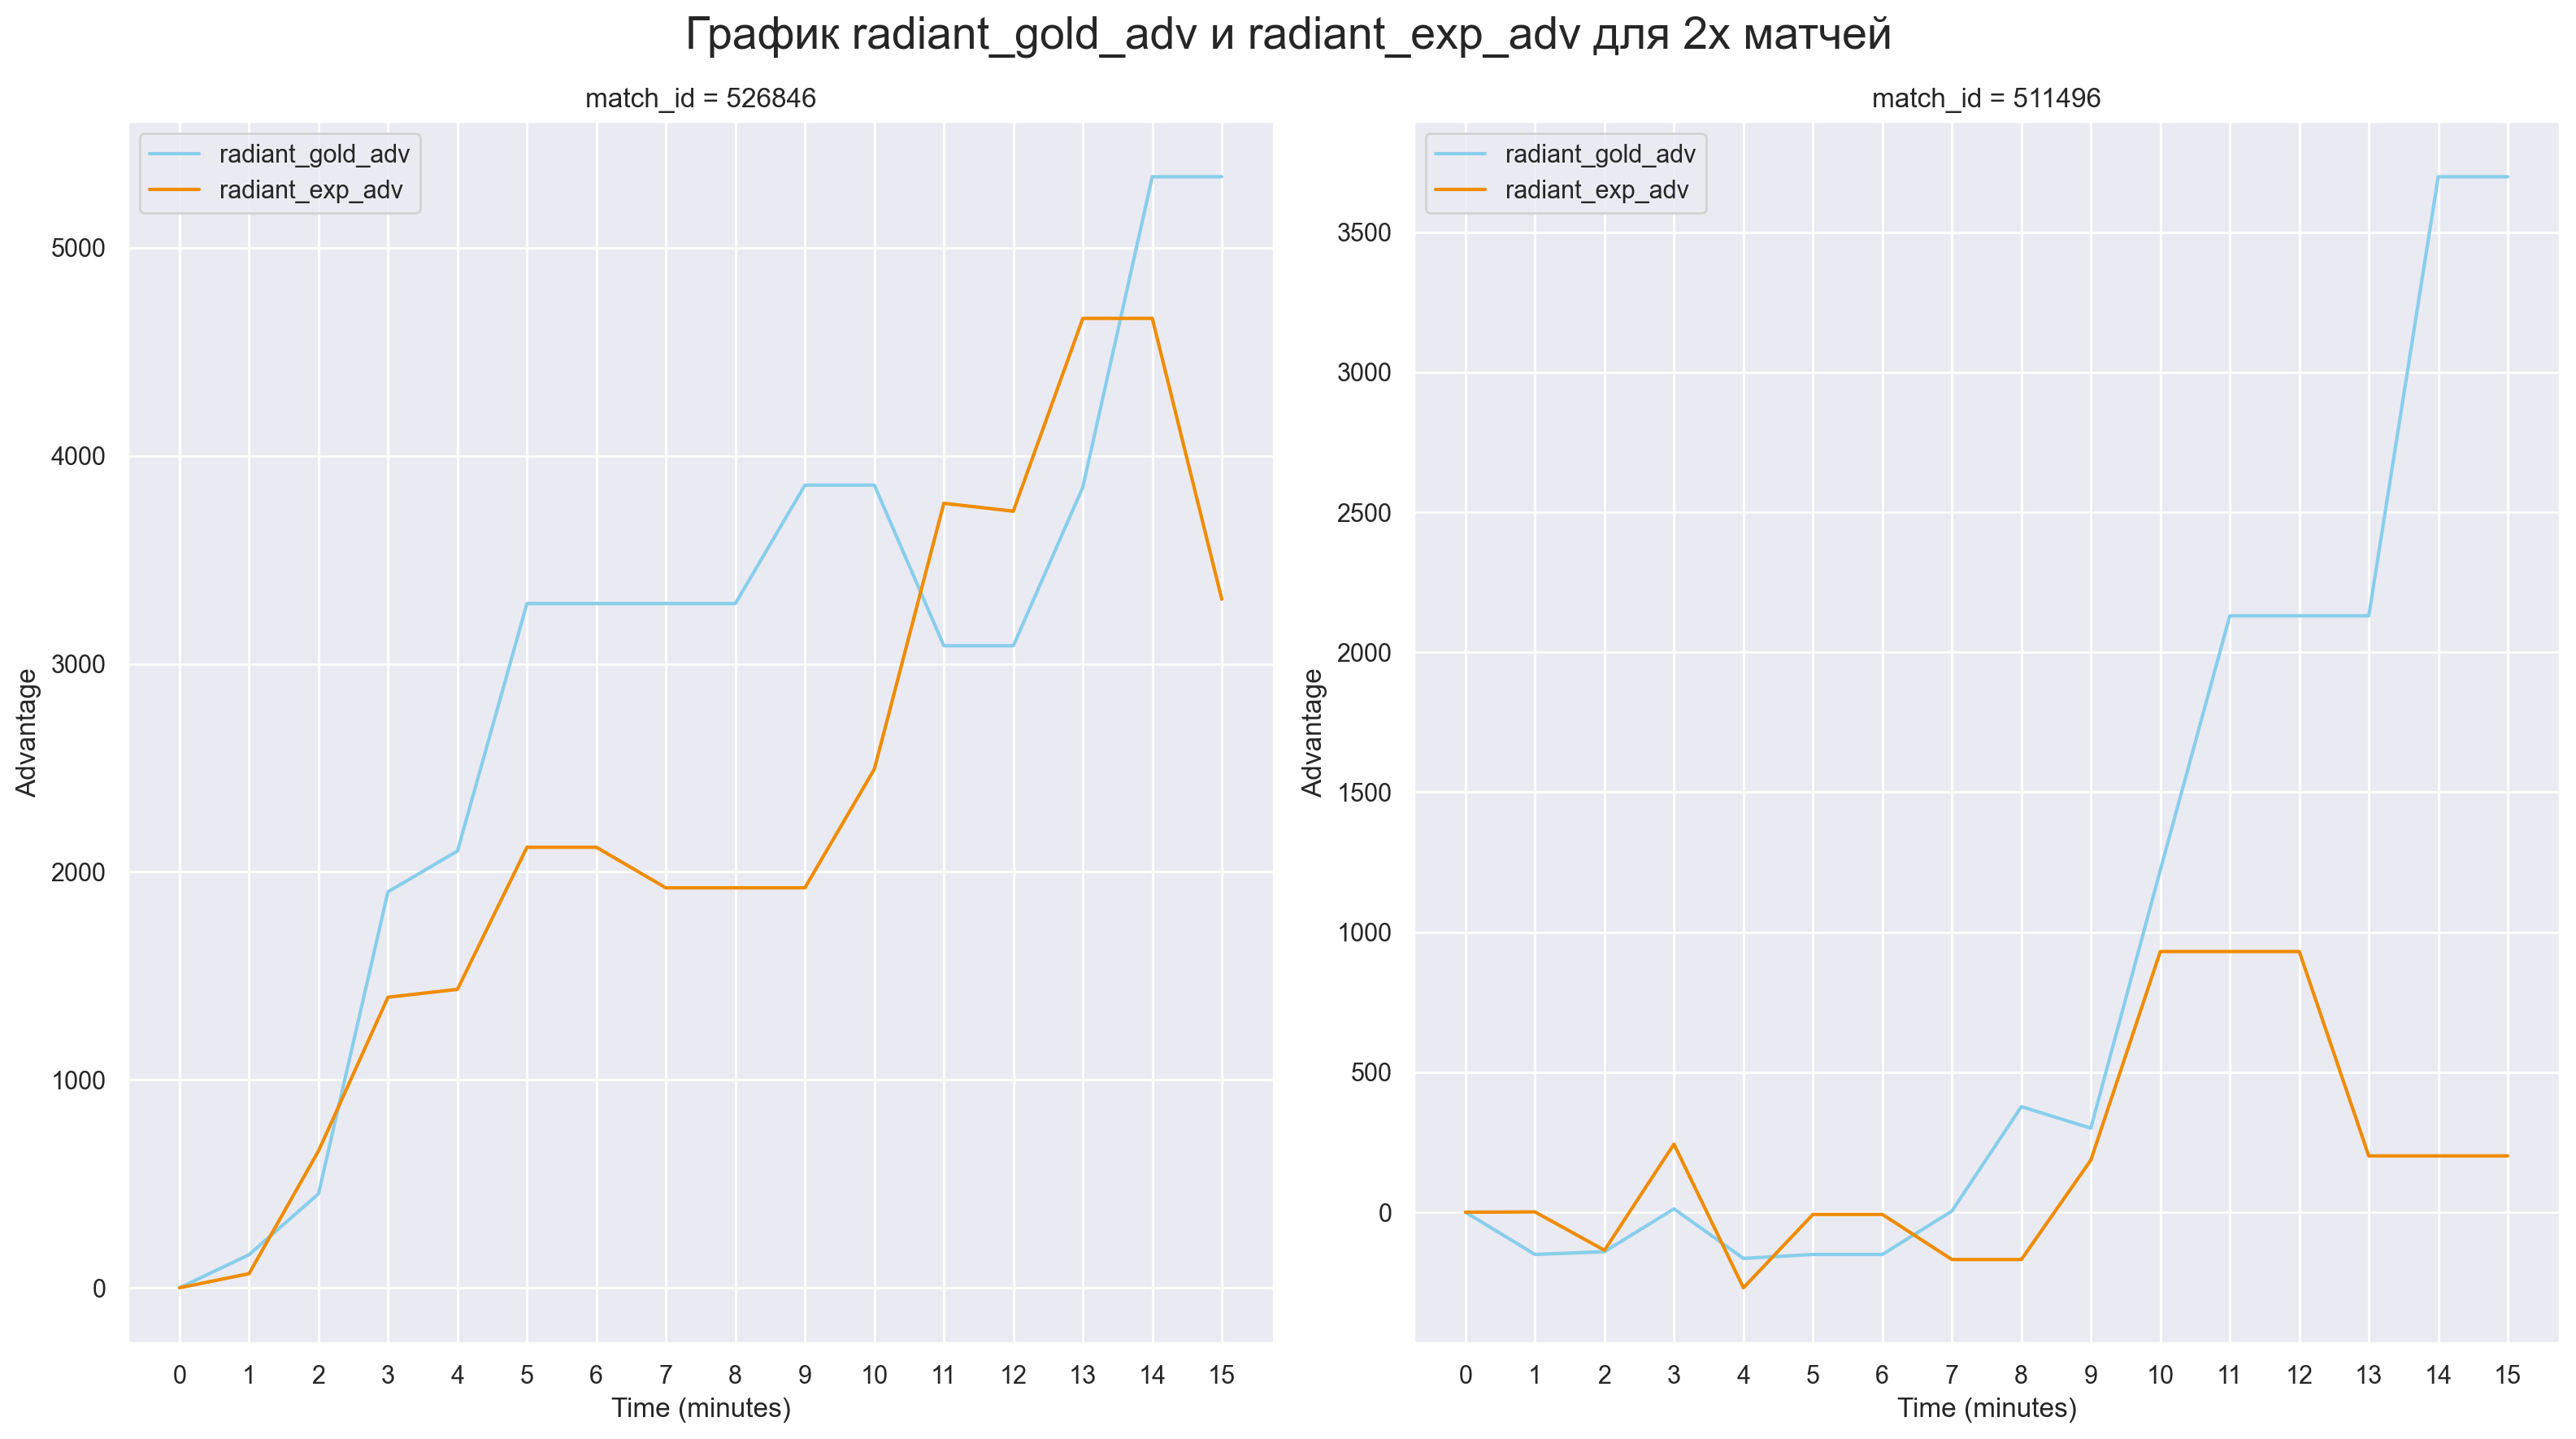

In [53]:
plt.figure(figsize=(16, 9))
plt.suptitle('График radiant_gold_adv и radiant_exp_adv для 2х матчей', fontsize=20)

for i in range(2):
    plt.subplot(1, 2, i + 1)
    match_id = dota_adv.iloc[i]["match_id"]
    gold_adv = dota_adv.iloc[i]["radiant_gold_adv"]
    exp_adv = dota_adv.iloc[i]["radiant_exp_adv"]

    plt.plot(gold_adv, label='radiant_gold_adv', color='skyblue')
    plt.plot(exp_adv, label='radiant_exp_adv', color='#EF8C00')

    plt.title(f'match_id = {match_id}')

    plt.xticks(ticks=np.arange(0, len(gold_adv)))
    plt.xlabel('Time (minutes)')
    plt.ylabel('Advantage')

    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


Для начала возьмём простые агрегации. Я предлагаю взять mean, std, max_lead, lead_switches и, как 5 -- last_*_adv (технически это ни статистика из библиотеки, поэтому в счет не пойдет). Обоснование:

- mean -- просто базово покажет среднее преимущество/отставание в первые 15 минут. Как по мне отличная метрика.

- std -- покажет то, насколько уверенно доминирует та или иная команда. Модель по нему поймет насколько в матче сильно менялолсь преимущество/отставание в течении времени

- max_val (aka max_lead) может тоже уточнить то, насколько все было хорошо у стороны света (+ ее можно отличным образом разбить на dire и radiant).

- cumsum -- они +- об одном и том же с mean, только cumsum будет показывать накапливающееся преимущество/отставание в течении срока. Но вероятно приведет к переобучению, так как мы настакаем похожих признаков (15 штук на cumsum).

- Количество смен знака покажет насколько стабильно доминировала та или иная команда, были ли камбеки. Поможет окорректировать вклад победы/проигрыша одной из сторон.

- Самое последнее измерение тоже очень показательно, ведь это последняя инфа, по которой мы можем определить текущего победителя на карте.


А также дополнительно мы возьмем следующее разбиение: max_lead -> max_dire_lead, max_radiant_lead. Это логично и понятно, модель поймет как каждая команда показала себя в пике.


In [54]:
def count_zero_crossings(adv_list):
    signs = np.sign(adv_list)
    signs = signs[signs != 0]
    crossings = np.where(np.diff(signs))[0]

    return len(crossings)

def get_advanced_stats(adv_series):
    if len(adv_series) == 0:
        return pd.Series({
            "mean": 0,
            "std": 0,
            "max_dire_lead": 0,
            "max_radiant_lead": 0,
            "lead_switches": 0,
            "last_adv_value": 0
        })

    return pd.Series({
        "mean": np.mean(adv_series),
        "std": np.std(adv_series),
        "max_dire_lead": -np.min(adv_series),
        "max_radiant_lead": np.max(adv_series),
        "lead_switches": count_zero_crossings(adv_series),
        "last_adv_value": adv_series[-1]
    })

def extract_features_from_dota_adv(dota_adv):
    features = pd.DataFrame(index=dota_adv.index)
    features["match_id"] = dota_adv["match_id"]
    for adv_type in ["gold", "exp"]:
        adv_col_name = f"radiant_{adv_type}_adv"
        adv_stats = dota_adv[adv_col_name].apply(get_advanced_stats)
        adv_stats.columns = [f"{adv_type}_{col}" for col in adv_stats.columns]
        features = features.join(adv_stats)
    return features

dota_adv_features = extract_features_from_dota_adv(dota_adv)
dota_adv_features.head()

,match_id,gold_mean,gold_std,gold_max_dire_lead,gold_max_radiant_lead,gold_lead_switches,gold_last_adv_value,exp_mean,exp_std,exp_max_dire_lead,exp_max_radiant_lead,exp_lead_switches,exp_last_adv_value
0,526846,2887.500,1559.052797,0.0,5342.0,0.0,5342.0,2262.250,1401.628406,0.0,4661.0,0.0,3311.0
1,511496,933.875,1342.763702,165.0,3698.0,3.0,3698.0,191.625,385.377717,270.0,931.0,4.0,201.0
2,90272,0.000,0.000000,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.0,0.0
3,153647,0.000,0.000000,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.0,0.0
4,694826,0.000,0.000000,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.0,0.0


In [55]:
# разобьем признаки на несколько групп и посмотрим на качество модели, обученной на каждой группе признаков по отдельности. Ну и на всех сразу тоже.
only_gold_features = [col for col in dota_adv_features.columns if col.startswith("gold")]
only_exp_features = [col for col in dota_adv_features.columns if col.startswith("exp")]

mean_and_std_features = [col for col in dota_adv_features.columns if "mean" in col or "std" in col]
max_lead_features = [col for col in dota_adv_features.columns if "max" in col]
last_value_features = [col for col in dota_adv_features.columns if "last_value" in col]

dota_adv_features.set_index("match_id", inplace=True)
all_adv_features = dota_adv_features.columns.tolist()
dota_adv_features.reset_index(inplace=True)

In [56]:
match_df_train = match_df_train.merge(dota_adv_features, on="match_id", how="left")
match_df_train[all_adv_features] = match_df_train[all_adv_features].fillna(0).astype(int)
match_df_test = match_df_test.merge(dota_adv_features, on="match_id", how="left")
match_df_test[all_adv_features] = match_df_test[all_adv_features].fillna(0).astype(int)

In [ ]:
evaluate_model(optimal_features, "Старый набор фичей")
evaluate_model(optimal_features + only_gold_features, "Старый набор фичей + только фичи по золоту")
evaluate_model(optimal_features + only_exp_features, "Старый набор фичей + только фичи по опыту")
evaluate_model(optimal_features + mean_and_std_features, "Старый набор фичей + только mean и std")
evaluate_model(optimal_features + max_lead_features, "Старый набор фичей + только max_lead")
evaluate_model(optimal_features + last_value_features, "Старый набор фичей + только last_value")
evaluate_model(optimal_features + all_adv_features, "Старый набор фичей + все фичи по dota_adv")

Старый набор фичей:
Средний Gini на Train: 0.3198
Средний Gini на Val:   0.3166
Старый набор фичей + только фичи по золоту:
Средний Gini на Train: 0.3883
Средний Gini на Val:   0.3863
Старый набор фичей + только фичи по опыту:
Средний Gini на Train: 0.3604
Средний Gini на Val:   0.3600


/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Старый набор фичей + только mean и std:
Средний Gini на Train: 0.3586
Средний Gini на Val:   0.3582


/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Старый набор фичей + только max_lead:
Средний Gini на Train: 0.3675
Средний Gini на Val:   0.3669
Старый набор фичей + только last_value:
Средний Gini на Train: 0.3198
Средний Gini на Val:   0.3166


/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Старый набор фичей + все фичи по dota_adv:
Средний Gini на Train: 0.4055
Средний Gini на Val:   0.4043


In [62]:
optimal_features = optimal_features + all_adv_features

#### **Тренд**

Если команда с треском проигрывает в первые 15 минут матча, возможно это признак камбека в следующие 50, как знать? Попробуем собрать агрегацию похитрее - она будет обозначать тренд, который есть в графиках преимущества, и если пословица верна, наша модель уловит эту зависимость.

С помощью вектора можно попробовать предугадать, что будет происходить в последующее время матча. Это как производная -- показывает как быстро adv золота/опыта растет или падает. Так что она точно очень полезна и может помочь модели предсказать исход матча.

In [ ]:
from typing import Iterable

class TrendTransformer:

    def __init__(self, columns: Iterable[str], method: str = "delta"):
        self.columns = columns
        self.method = method

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X_copy = X.copy()

        for col in self.columns:
            stats = X[col].apply(self._get_trend_stats)
            stats.columns = [f"{col}_{c}" for c in stats.columns]
            X_copy = pd.concat([X_copy, stats], axis=1)

        return X_copy

    def _get_trend_stats(self, adv_list):
        if len(adv_list) == 0:
            return pd.Series({'slope': 0, 'intercept': 0, 'r2': 0})

        slope = 0
        intercept = 0
        r2 = 0

        if self.method == "delta":
            slope = (adv_list[-1] - adv_list[0]) / len(adv_list)
            intercept = adv_list[0]
        elif self.method == "OLS":
            y = adv_list
            x = np.arange(len(adv_list))
            slope, intercept = np.polyfit(x, y, 1)
            y_pred = slope * x + intercept
            r2 = r2_score(y, y_pred)

        return pd.Series({'slope': slope, 'intercept': intercept, 'r2': r2})

In [ ]:
trend_tranformer = TrendTransformer(columns=['radiant_gold_adv', 'radiant_exp_adv'], method="OLS")

dota_with_trends = trend_tranformer.transform(dota_adv)

In [ ]:
display(dota_with_trends.head())
dota_with_trends.drop(columns=["radiant_gold_adv", "radiant_exp_adv"], inplace=True)

dota_adv_features.set_index("match_id", inplace=True)
all_trend_features = dota_with_trends.columns.tolist()
dota_adv_features.reset_index(inplace=True)
all_trend_features

,match_id,radiant_gold_adv,radiant_exp_adv,radiant_gold_adv_slope,radiant_gold_adv_intercept,radiant_gold_adv_r2,radiant_exp_adv_slope,radiant_exp_adv_intercept,radiant_exp_adv_r2
0,526846,"[0, 159, 452, 1904, 2100, 3290, 3290, 3290, 32...","[0, 68, 658, 1397, 1435, 2118, 2118, 1923, 192...",304.388235,604.588235,0.810015,282.491176,143.566176,0.863183
1,511496,"[0, -151, -141, 12, -165, -151, -151, 4, 377, ...","[0, 1, -136, 243, -270, -8, -8, -169, -169, 18...",256.185294,-987.514706,0.773514,42.938235,-130.411765,0.263800
2,90272,[],[],0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,153647,[],[],0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,694826,[],[],0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


['match_id',
 'radiant_gold_adv_slope',
 'radiant_gold_adv_intercept',
 'radiant_gold_adv_r2',
 'radiant_exp_adv_slope',
 'radiant_exp_adv_intercept',
 'radiant_exp_adv_r2']

In [ ]:
match_df_train = match_df_train.merge(dota_with_trends, on="match_id", how="left")
match_df_train[all_trend_features] = match_df_train[all_trend_features].fillna(0).astype(int)
match_df_test = match_df_test.merge(dota_with_trends, on="match_id", how="left")
match_df_test[all_trend_features] = match_df_test[all_trend_features].fillna(0).astype(int)

In [ ]:
evaluate_model(optimal_features, "Старый набор фичей")
evaluate_model(optimal_features + all_trend_features, "Старый набор фичей + трендовые фичи")

Старый набор фичей:
Средний Gini на Train: 0.4055
Средний Gini на Val:   0.4043
Старый набор фичей + трендовые фичи:
Средний Gini на Train: 0.4071
Средний Gini на Val:   0.4060


Прирост конечно есть, но он минимальный)

In [ ]:
optimal_features = optimal_features + all_trend_features

#### **Бинаризация**

Попробуем реальзовать бинаризацию, как она работает:

1. Берётся отрезок advantage и разбивается на несколько бинов
2. Бины можно использовать, как фичу саму по себе, а можно подсобрать внутри неё агрегации

Во-первых, ваша модель внезапно становится нелинейной, хоть и кусочной, это круто \
В-вторых, это фильтрует шумный сигнал, выбросы то отлетят в соответствующий бин

In [ ]:
class BinStaticticTransformer:
    def __init__(self, columns: Iterable[str], n_bins: int = 3, add_last_value: bool = True):
        self.columns = columns
        self.n_bins = n_bins
        self.add_last_value = add_last_value

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X_copy = X.copy()
        new_features = []

        for col in self.columns:
            stats = X[col].apply(self._get_binned_stats)
            stats.columns = [f"{col}_{c}" for c in stats.columns]
            new_features.append(stats)

            if self.add_last_value:
                X_copy[f"{col}_last_adv_value"] = X[col].apply(lambda x: x[-1] if len(x) > 0 else 0)

        return pd.concat([X_copy] + new_features, axis=1)

    def _get_binned_stats(self, adv_list):
        res = {}
        if len(adv_list) == 0:
            for i in range(self.n_bins):
                res.update({
                    f"bin_{i}_mean": 0,
                    f"bin_{i}_std": 0,
                    f"bin_{i}_max_dire_lead": 0,
                    f"bin_{i}_max_radiant_lead": 0,
                    f"bin_{i}_lead_switches": 0,
                })
            return pd.Series(res)

        bins = np.array_split(adv_list, self.n_bins)
        for i, adv_bin in enumerate(bins):
            bin_stats = self._get_bin_advanced_stat(adv_bin)
            for stat_name, stat_val in bin_stats.items():
                res[f"bin_{i}_{stat_name}"] = stat_val

        return pd.Series(res)


    def _get_bin_advanced_stat(self, adv_bin):
        if len(adv_bin) == 0:
            return {
                "mean": 0,
                "std": 0,
                "max_dire_lead": 0,
                "max_radiant_lead": 0,
                "lead_switches": 0,
            }

        return {
            "mean": np.mean(adv_bin),
            "std": np.std(adv_bin),
            "max_dire_lead": -np.min(adv_bin),
            "max_radiant_lead": np.max(adv_bin),
            "lead_switches": self._count_zero_crossings(adv_bin),
        }

    @staticmethod
    def _count_zero_crossings(arr):
        signs = np.sign(arr)
        signs = signs[signs != 0]
        crossings = np.where(np.diff(signs))[0]

        return len(crossings)


In [ ]:
bin_statictic_tranformer = BinStaticticTransformer(columns=['radiant_gold_adv', 'radiant_exp_adv'])

dota_with_bin_stats = bin_statictic_tranformer.transform(dota_adv)

In [ ]:
dota_with_bin_stats.head()

,match_id,radiant_gold_adv,radiant_exp_adv,radiant_gold_adv_last_adv_value,radiant_exp_adv_last_adv_value,radiant_gold_adv_bin_0_mean,radiant_gold_adv_bin_0_std,radiant_gold_adv_bin_0_max_dire_lead,radiant_gold_adv_bin_0_max_radiant_lead,radiant_gold_adv_bin_0_lead_switches,...,radiant_exp_adv_bin_1_mean,radiant_exp_adv_bin_1_std,radiant_exp_adv_bin_1_max_dire_lead,radiant_exp_adv_bin_1_max_radiant_lead,radiant_exp_adv_bin_1_lead_switches,radiant_exp_adv_bin_2_mean,radiant_exp_adv_bin_2_std,radiant_exp_adv_bin_2_max_dire_lead,radiant_exp_adv_bin_2_max_radiant_lead,radiant_exp_adv_bin_2_lead_switches
0,526846,"[0, 159, 452, 1904, 2100, 3290, 3290, 3290, 32...","[0, 68, 658, 1397, 1435, 2118, 2118, 1923, 192...",5342,3311,1317.500000,1202.363194,0.0,3290.0,0.0,...,2076.2,222.132753,-1923.0,2494.0,0.0,4027.8,541.745106,-3311.0,4661.0,0.0
1,511496,"[0, -151, -141, 12, -165, -151, -151, 4, 377, ...","[0, 1, -136, 243, -270, -8, -8, -169, -169, 18...",3698,201,-99.333333,74.888065,165.0,12.0,2.0,...,154.2,409.793802,169.0,931.0,1.0,493.0,357.625502,-201.0,931.0,0.0
2,90272,[],[],0,0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,153647,[],[],0,0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,694826,[],[],0,0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


In [ ]:
all_bin_stats_features = dota_with_bin_stats.columns.difference(dota_adv.columns).tolist()
all_bin_stats_features

['radiant_exp_adv_bin_0_lead_switches',
 'radiant_exp_adv_bin_0_max_dire_lead',
 'radiant_exp_adv_bin_0_max_radiant_lead',
 'radiant_exp_adv_bin_0_mean',
 'radiant_exp_adv_bin_0_std',
 'radiant_exp_adv_bin_1_lead_switches',
 'radiant_exp_adv_bin_1_max_dire_lead',
 'radiant_exp_adv_bin_1_max_radiant_lead',
 'radiant_exp_adv_bin_1_mean',
 'radiant_exp_adv_bin_1_std',
 'radiant_exp_adv_bin_2_lead_switches',
 'radiant_exp_adv_bin_2_max_dire_lead',
 'radiant_exp_adv_bin_2_max_radiant_lead',
 'radiant_exp_adv_bin_2_mean',
 'radiant_exp_adv_bin_2_std',
 'radiant_exp_adv_last_adv_value',
 'radiant_gold_adv_bin_0_lead_switches',
 'radiant_gold_adv_bin_0_max_dire_lead',
 'radiant_gold_adv_bin_0_max_radiant_lead',
 'radiant_gold_adv_bin_0_mean',
 'radiant_gold_adv_bin_0_std',
 'radiant_gold_adv_bin_1_lead_switches',
 'radiant_gold_adv_bin_1_max_dire_lead',
 'radiant_gold_adv_bin_1_max_radiant_lead',
 'radiant_gold_adv_bin_1_mean',
 'radiant_gold_adv_bin_1_std',
 'radiant_gold_adv_bin_2_lead_switc

In [ ]:
match_df_train = match_df_train.merge(dota_with_bin_stats, on="match_id", how="left")
match_df_train[all_bin_stats_features] = match_df_train[all_bin_stats_features].fillna(0).astype(int)
match_df_test = match_df_test.merge(dota_with_bin_stats, on="match_id", how="left")
match_df_test[all_bin_stats_features] = match_df_test[all_bin_stats_features].fillna(0).astype(int)

In [ ]:
evaluate_model(optimal_features, "Старый набор фичей")
evaluate_model(list(set(optimal_features) - set(all_trend_features)) + all_bin_stats_features, "Старый набор фичей - все фичи из 5.1 + их бинованные версии")

Старый набор фичей:
Средний Gini на Train: 0.4071
Средний Gini на Val:   0.4060


/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Старый набор фичей - все фичи из 5.1 + их бинованные версии:
Средний Gini на Train: 0.4096
Средний Gini на Val:   0.4079


In [ ]:
optimal_features = list(set(optimal_features) - set(all_trend_features)) + all_bin_stats_features

### **Часть 5. А что можно еще придумать?** <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4f/Emoticon_blush.gif/revision/latest?cb=20180504011409">

##### 1. Агрегация командных показателей (Свет vs Тьма)

Вместо 10 строк на матч нужно получить одну. Для этого группируем по `match_id` и разделяем по `player_slot` (0-4 — Свет, 128-132 — Тьма).

* **Суммы и Средние:** Суммарный `gold`, `xp_per_min`, `hero_damage`, `tower_damage` для каждой команды.
* **Дельты (Разницы):** Самый сильный сигнал для бустинга. Вычитаем показатели Тьмы из показателей Света: `radiant_total_gold - dire_total_gold` или `radiant_total_kills - dire_total_kills`.
* **Отношения (Ratios):** Доля Света в общем пуле. Например: `radiant_gold / (radiant_gold + dire_gold + 1)` (плюс 1, чтобы избежать деления на ноль).

##### 2. Идентификация ролей по внутриигровой статистике

В Доте ресурсы распределяются неравномерно. Полезно смотреть не только на сумму, но и на распределение внутри команды:

* **Топ-фармер (Керри/Мидер):** Возьмем `max()` по `gold` или `last_hits` внутри команды. Сравни топ-1 игрока Света с топ-1 игроком Тьмы.
* **Саппорты:** Возьми `min()` по `gold_per_min`. Если у саппорта Света GPM сильно выше саппорта Тьмы, возможно, у них больше ассистов или они сломали вышки.
* **Разрыв в фарме:** `max(gold) - min(gold)` внутри одной команды. Показывает, насколько ресурсы сконцентрированы на одном игроке ("жадный" пик).

##### 3. Фичи на основе поведения
* **KDA:** Формула `(kills + assists) / (deaths + 1)` для каждой команды.

##### 4. Скрещивание Героев и Игроков

Сделаем `merge` датафрейма с `Constants.Heroes.csv`:

* **Фарм по типу атрибута:** Посчитаем суммарный `gold` только для героев с `primary_attr == 'agi'` (ловкачи) в каждой команде.
* **Эффективность ролей:** Если герой имеет роль 'Support' в `Constants.Heroes.csv`, проверь его `last_hits`. Если саппорты забирают много крипов, это негативный сигнал — керри недополучает фарм.

А теперь реальзуем пайплайн обучения. И соответсвенно, реализуем эти идеи там.

Но для начала проведем одну проверку, какие сведенья по игрокам мы знаем для тестовой выборки:

In [63]:
df_test = pd.read_csv(f"{data_folder_name}/matches_df_test.csv")

In [ ]:
df_test.merge(players_df, on=["match_id"])

,match_id,date,region,game_mode,avg_mmr,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,is_radiant_team
0,8,2024-12-01,China,1,2305.0,131,74394157,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,8,2024-12-01,China,1,2305.0,132,4294967295,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,8,2024-12-01,China,1,2305.0,2,4294967295,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,8,2024-12-01,China,1,2305.0,0,4294967295,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,8,2024-12-01,China,1,2305.0,1,4294967295,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594400,767816,2024-12-22,SE Asia,18,1649.2,3,4294967295,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
594401,767816,2024-12-22,SE Asia,18,1649.2,0,4294967295,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
594402,767816,2024-12-22,SE Asia,18,1649.2,4,4294967295,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
594403,767816,2024-12-22,SE Asia,18,1649.2,129,4294967295,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


Наши фичи будут юслесс, потому что для тестовой выборки их просто нет. Странно, почему бы не дать их за первые 15 минут и для train, и для test.